# Qwen2.5

## Video tasks

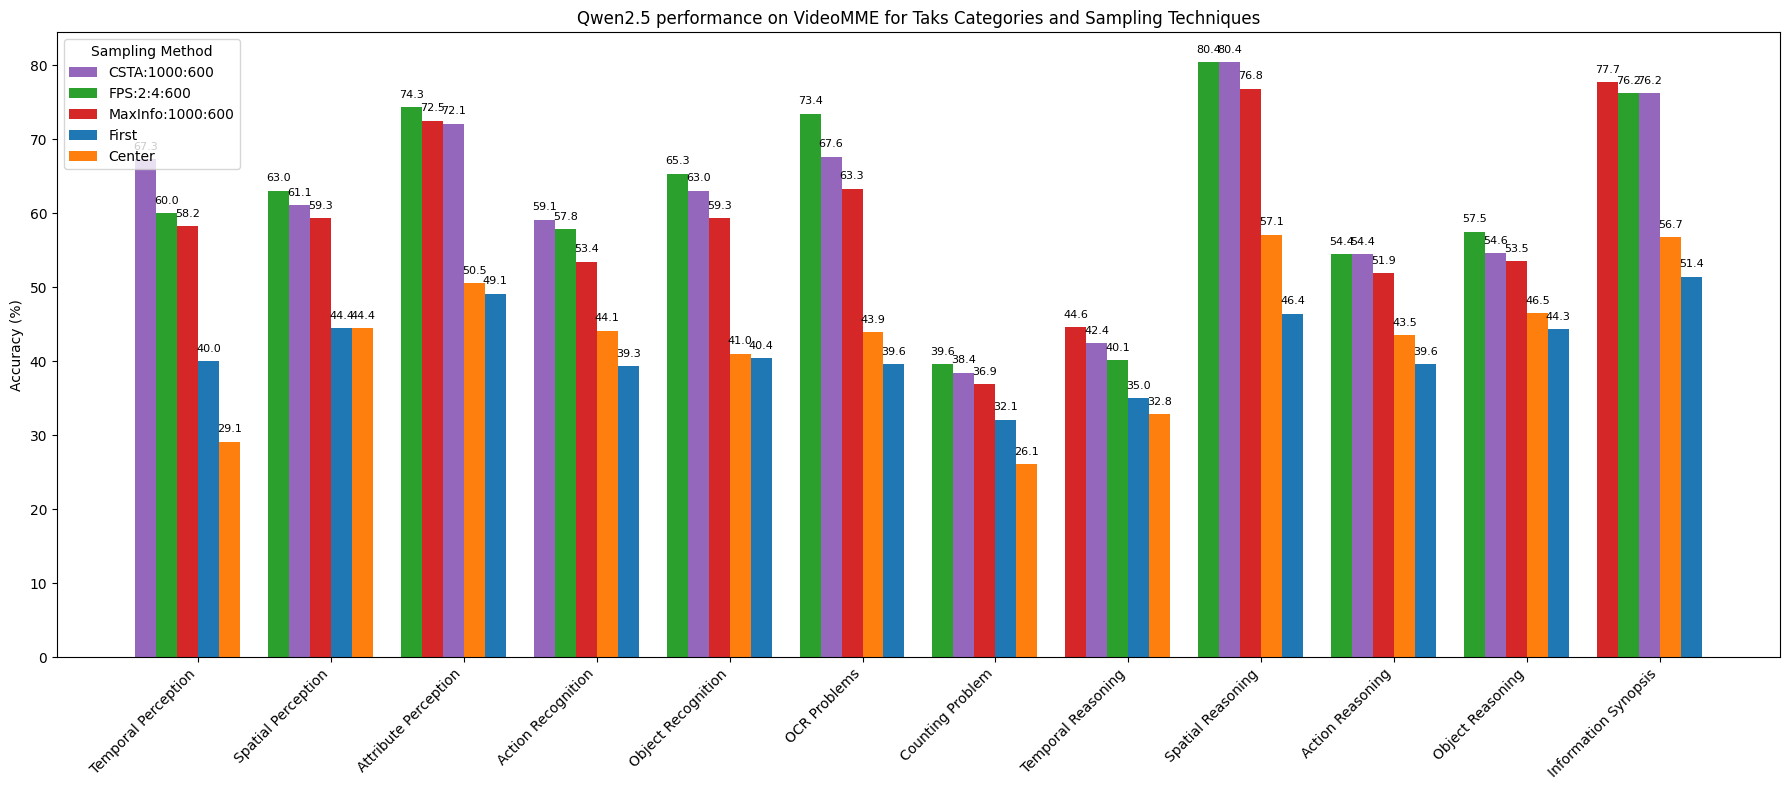

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "First": [40.0, 44.4, 49.1, 39.3, 40.4, 39.6, 32.1, 35.0, 46.4, 39.6, 44.3, 51.4],
    "Center": [29.1, 44.4, 50.5, 44.1, 41.0, 43.9, 26.1, 32.8, 57.1, 43.5, 46.5, 56.7],
    "FPS:2:4:600": [60.0, 63.0, 74.3, 57.8, 65.3, 73.4, 39.6, 40.1, 80.4, 54.4, 57.5, 76.2],
    "MaxInfo:1000:600": [58.2, 59.3, 72.5, 53.4, 59.3, 63.3, 36.9, 44.6, 76.8, 51.9, 53.5, 77.7],
    "CSTA:1000:600": [67.3, 61.1, 72.1, 59.1, 63.0, 67.6, 38.4, 42.4, 80.4, 54.4, 54.6, 76.2]
}

df = pd.DataFrame(data)
sampling_methods = ["First", "Center", "FPS:2:4:600", "MaxInfo:1000:600", "CSTA:1000:600"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("Qwen2.5 performance on VideoMME for Taks Categories and Sampling Techniques")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()


## Video Category

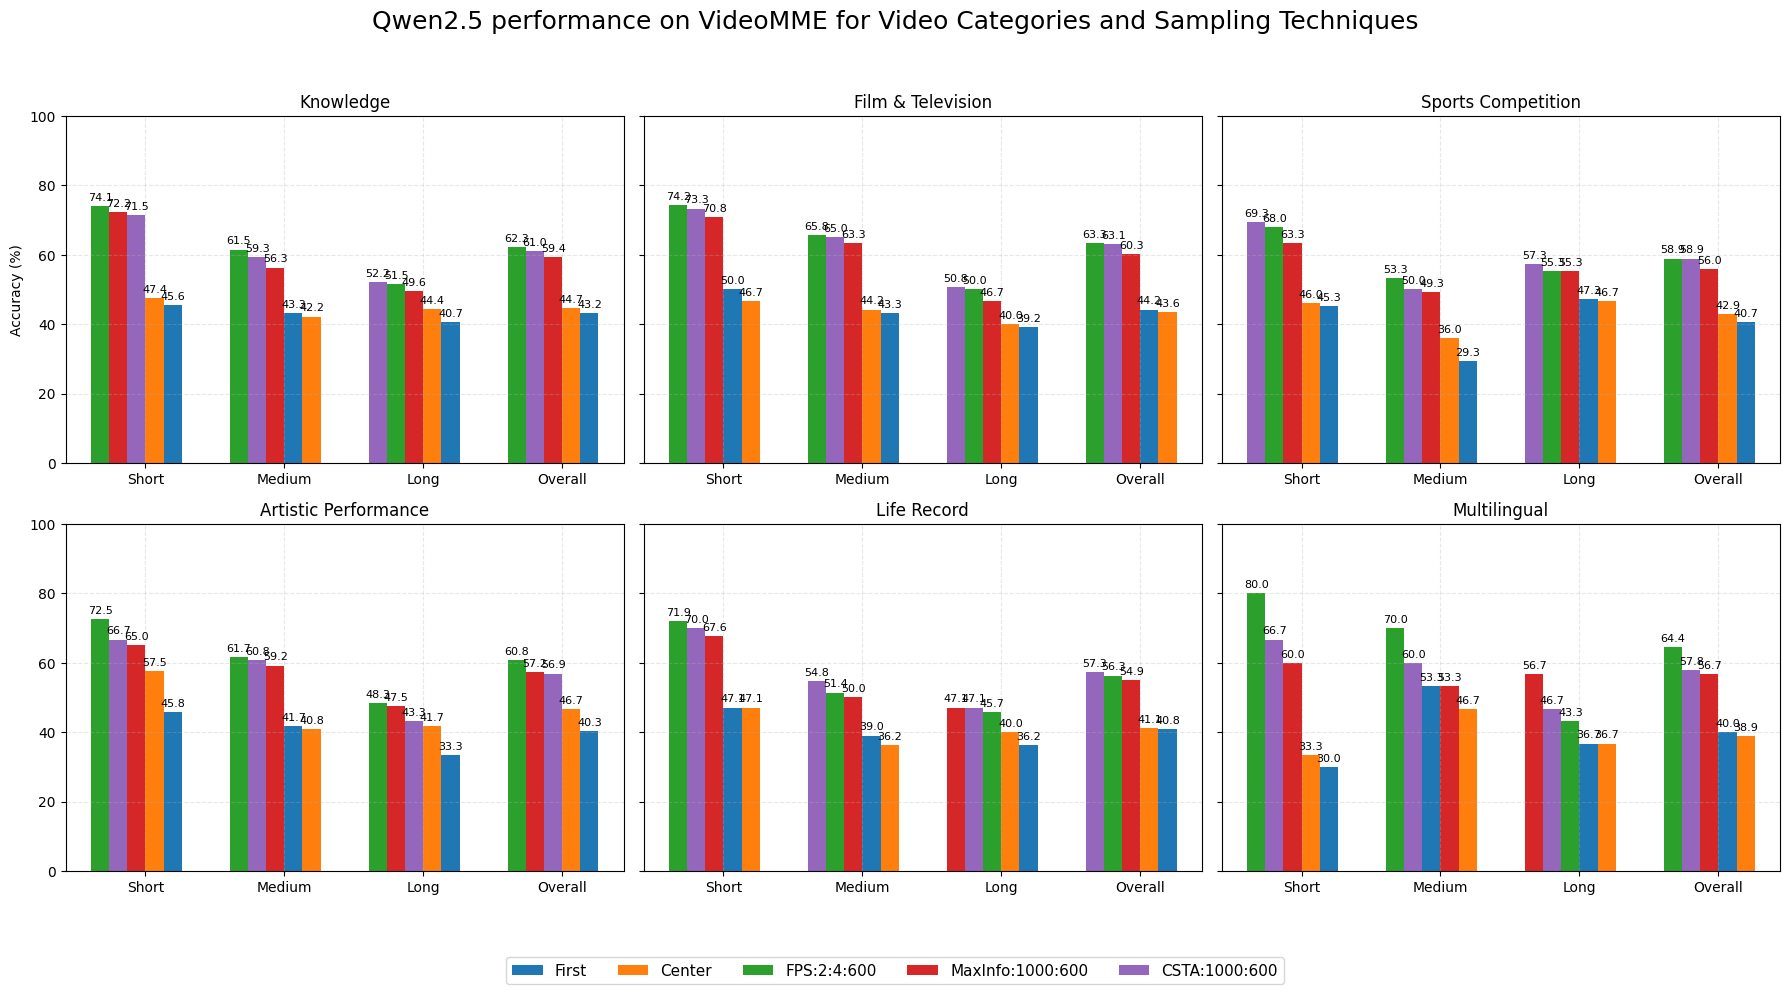

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


categories = {
    "Knowledge": {
        "Short":   [45.6, 47.4, 74.1, 72.2, 71.5],
        "Medium":  [43.3, 42.2, 61.5, 56.3, 59.3],
        "Long":    [40.7, 44.4, 51.5, 49.6, 52.2],
        "Overall": [43.2, 44.7, 62.3, 59.4, 61.0],
    },
    "Film & Television": {
        "Short":   [50.0, 46.7, 74.2, 70.8, 73.3],
        "Medium":  [43.3, 44.2, 65.8, 63.3, 65.0],
        "Long":    [39.2, 40.0, 50.0, 46.7, 50.8],
        "Overall": [44.2, 43.6, 63.3, 60.3, 63.1],
    },
    "Sports Competition": {
        "Short":   [45.3, 46.0, 68.0, 63.3, 69.3],
        "Medium":  [29.3, 36.0, 53.3, 49.3, 50.0],
        "Long":    [47.3, 46.7, 55.3, 55.3, 57.3],
        "Overall": [40.7, 42.9, 58.9, 56.0, 58.9],
    },
    "Artistic Performance": {
        "Short":   [45.8, 57.5, 72.5, 65.0, 66.7],
        "Medium":  [41.7, 40.8, 61.7, 59.2, 60.8],
        "Long":    [33.3, 41.7, 48.3, 47.5, 43.3],
        "Overall": [40.3, 46.7, 60.8, 57.2, 56.9],
    },
    "Life Record": {
        "Short":   [47.1, 47.1, 71.9, 67.6, 70.0],
        "Medium":  [39.0, 36.2, 51.4, 50.0, 54.8],
        "Long":    [36.2, 40.0, 45.7, 47.1, 47.1],
        "Overall": [40.8, 41.1, 56.3, 54.9, 57.3],
    },
    "Multilingual": {
        "Short":   [30.0, 33.3, 80.0, 60.0, 66.7],
        "Medium":  [53.3, 46.7, 70.0, 53.3, 60.0],
        "Long":    [36.7, 36.7, 43.3, 56.7, 46.7],
        "Overall": [40.0, 38.9, 64.4, 56.7, 57.8],
    },
}


sampling_methods = ["First", "Center", "FPS:2:4:600", "MaxInfo:1000:600", "CSTA:1000:600"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Qwen2.5 performance on VideoMME for Video Categories and Sampling Techniques", fontsize=18)

for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()


## MaxInfo different parameters comparison

### Video tasks

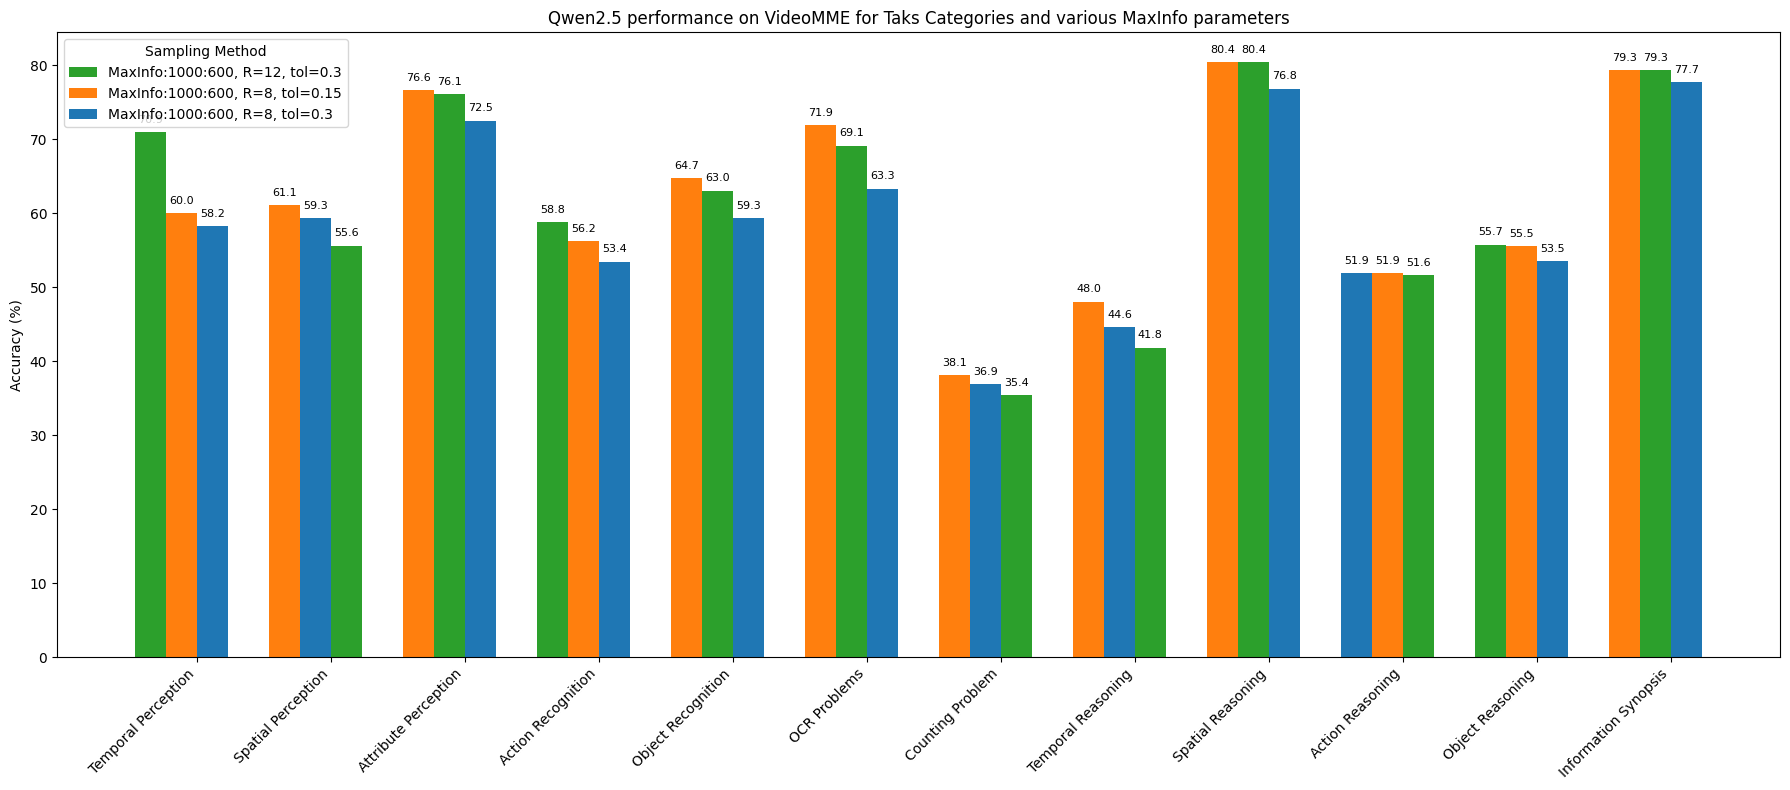

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "MaxInfo:1000:600, R=8, tol=0.3": [58.2, 59.3, 72.5, 53.4, 59.3, 63.3, 36.9, 44.6, 76.8, 51.9, 53.5, 77.7],
    "MaxInfo:1000:600, R=8, tol=0.15": [60.0, 61.1, 76.6, 56.2, 64.7, 71.9, 38.1, 48.0, 80.4, 51.9, 55.5, 79.3],
    "MaxInfo:1000:600, R=12, tol=0.3": [70.9, 55.6, 76.1, 58.8, 63.0, 69.1, 35.4, 41.8, 80.4, 51.6, 55.7, 79.3]
}

df = pd.DataFrame(data)
sampling_methods = ["MaxInfo:1000:600, R=8, tol=0.3", "MaxInfo:1000:600, R=8, tol=0.15", "MaxInfo:1000:600, R=12, tol=0.3"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("Qwen2.5 performance on VideoMME for Taks Categories and various MaxInfo parameters")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()


### Video Categories

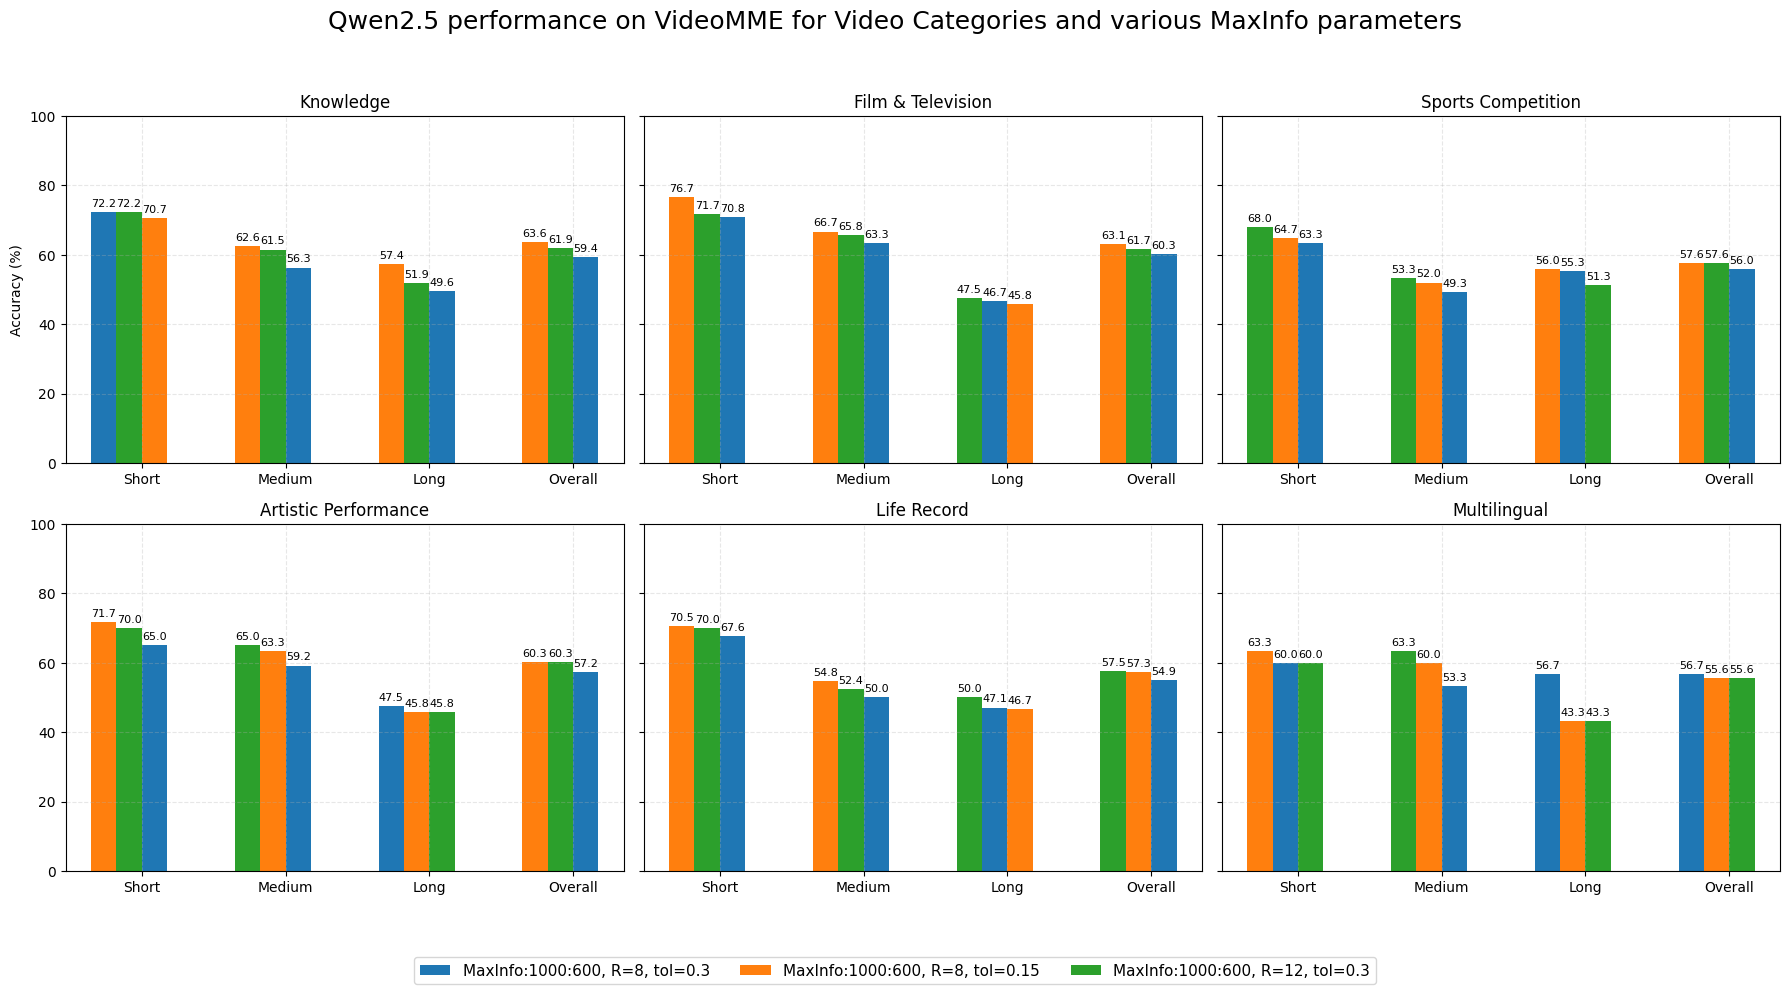

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


categories = {
    "Knowledge": {
        "Short":   [72.2, 70.7, 72.2],
        "Medium":  [56.3, 62.6, 61.5],
        "Long":    [49.6, 57.4, 51.9],
        "Overall": [59.4, 63.6, 61.9],
    },
    "Film & Television": {
        "Short":   [70.8, 76.7, 71.7],
        "Medium":  [63.3, 66.7, 65.8],
        "Long":    [46.7, 45.8, 47.5],
        "Overall": [60.3, 63.1, 61.7],
    },
    "Sports Competition": {
        "Short":   [63.3, 64.7, 68.0],
        "Medium":  [49.3, 52.0, 53.3],
        "Long":    [55.3, 56.0, 51.3],
        "Overall": [56.0, 57.6, 57.6],
    },
    "Artistic Performance": {
        "Short":   [65.0, 71.7, 70.0],
        "Medium":  [59.2, 63.3, 65.0],
        "Long":    [47.5, 45.8, 45.8],
        "Overall": [57.2, 60.3, 60.3],
    },
    "Life Record": {
        "Short":   [67.6, 70.5, 70.0],
        "Medium":  [50.0, 54.8, 52.4],
        "Long":    [47.1, 46.7, 50.0],
        "Overall": [54.9, 57.3, 57.5],
    },
    "Multilingual": {
        "Short":   [60.0, 63.3, 60.0],
        "Medium":  [53.3, 60.0, 63.3],
        "Long":    [56.7, 43.3, 43.3],
        "Overall": [56.7, 55.6, 55.6],
    },
}


sampling_methods = ["MaxInfo:1000:600, R=8, tol=0.3", "MaxInfo:1000:600, R=8, tol=0.15", "MaxInfo:1000:600, R=12, tol=0.3"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Qwen2.5 performance on VideoMME for Video Categories and various MaxInfo parameters", fontsize=18)

for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()


## CSTA different parameters comparison

### Video tasks

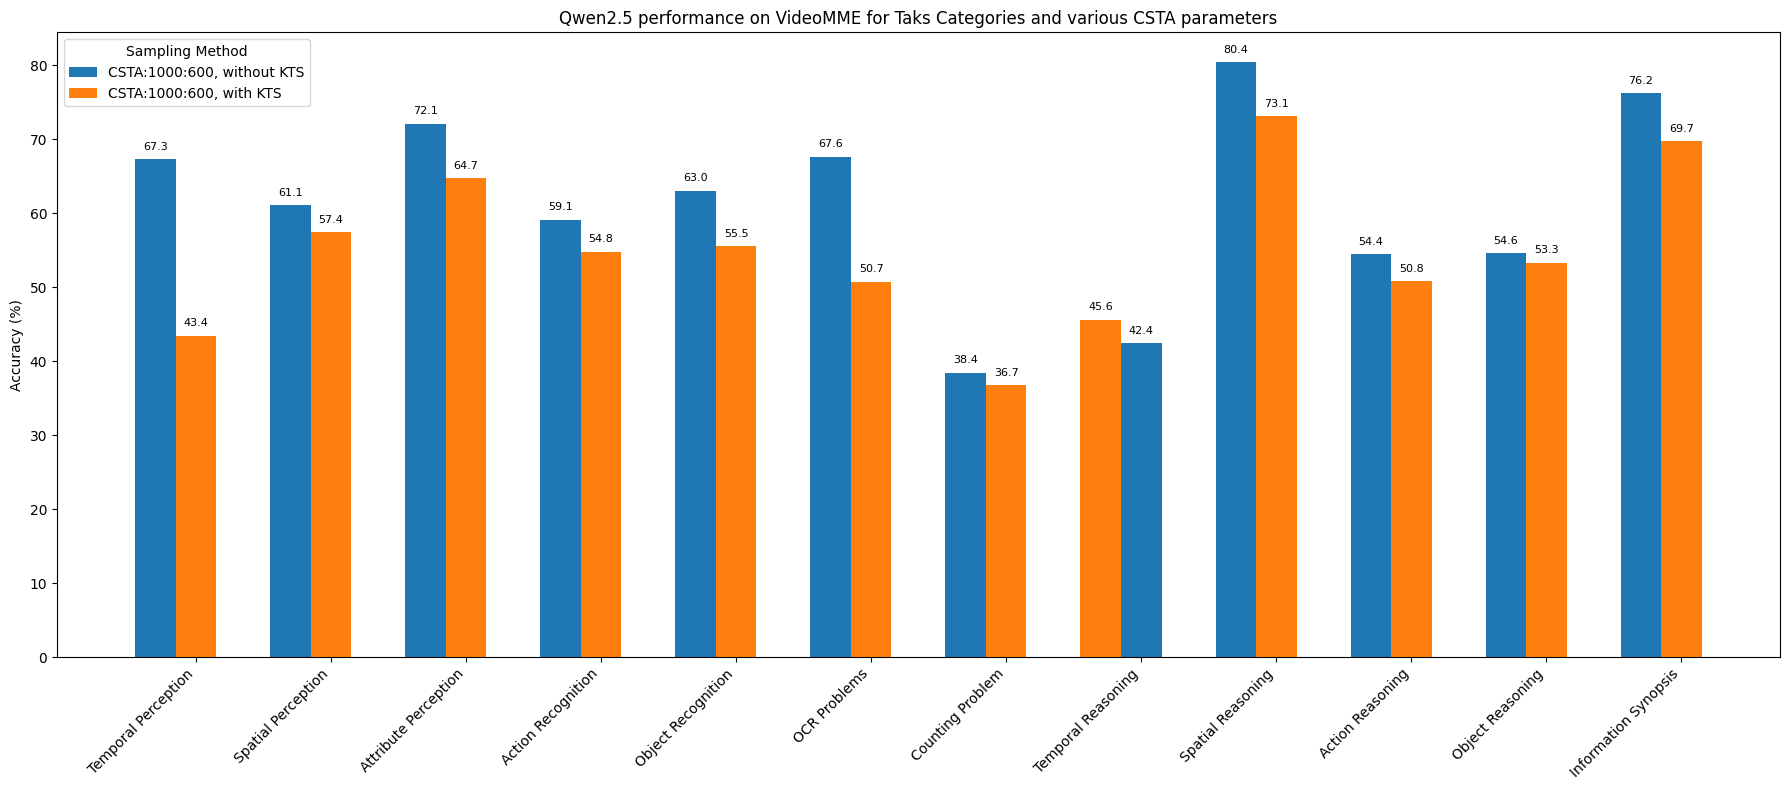

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "CSTA:1000:600, without KTS": [67.3, 61.1, 72.1, 59.1, 63.0, 67.6, 38.4, 42.4, 80.4, 54.4, 54.6, 76.2],
    "CSTA:1000:600, with KTS": [43.4, 57.4, 64.7, 54.8, 55.5, 50.7, 36.7, 45.6, 73.1, 50.8, 53.3, 69.7]
}

df = pd.DataFrame(data)
sampling_methods = ["CSTA:1000:600, without KTS", "CSTA:1000:600, with KTS"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("Qwen2.5 performance on VideoMME for Taks Categories and various CSTA parameters")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()


### Video categories

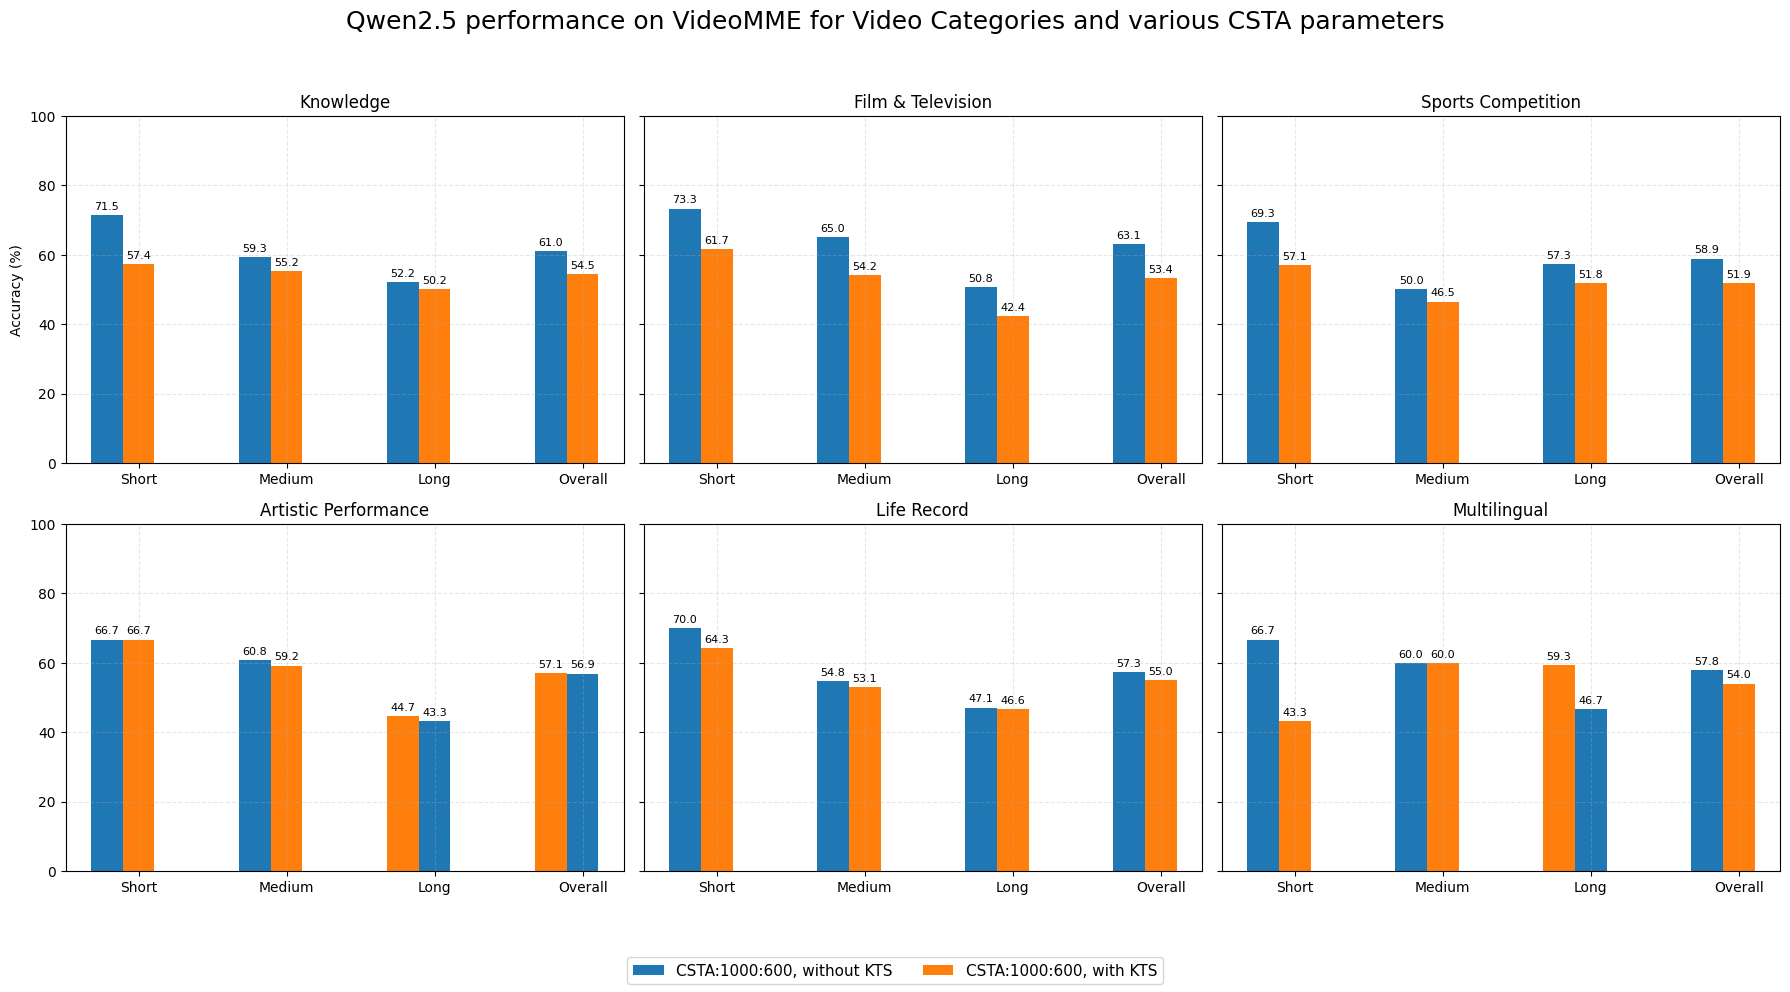

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


categories = {
    "Knowledge": {
        "Short":   [71.5, 57.4],
        "Medium":  [59.3, 55.2],
        "Long":    [52.2, 50.2],
        "Overall": [61.0, 54.5],
    },
    "Film & Television": {
        "Short":   [73.3, 61.7],
        "Medium":  [65.0, 54.2],
        "Long":    [50.8, 42.4],
        "Overall": [63.1, 53.4],
    },
    "Sports Competition": {
        "Short":   [69.3, 57.1],
        "Medium":  [50.0, 46.5],
        "Long":    [57.3, 51.8],
        "Overall": [58.9, 51.9],
    },
    "Artistic Performance": {
        "Short":   [66.7, 66.7],
        "Medium":  [60.8, 59.2],
        "Long":    [43.3, 44.7],
        "Overall": [56.9, 57.1],
    },
    "Life Record": {
        "Short":   [70.0, 64.3],
        "Medium":  [54.8, 53.1],
        "Long":    [47.1, 46.6],
        "Overall": [57.3, 55.0],
    },
    "Multilingual": {
        "Short":   [66.7, 43.3],
        "Medium":  [60.0, 60.0],
        "Long":    [46.7, 59.3],
        "Overall": [57.8, 54.0],
    },
}


sampling_methods = ["CSTA:1000:600, without KTS", "CSTA:1000:600, with KTS"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Qwen2.5 performance on VideoMME for Video Categories and various CSTA parameters", fontsize=18)

for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()


## Coparing performance of FPSm all MaxInfo and all CSTA 

### Video task 

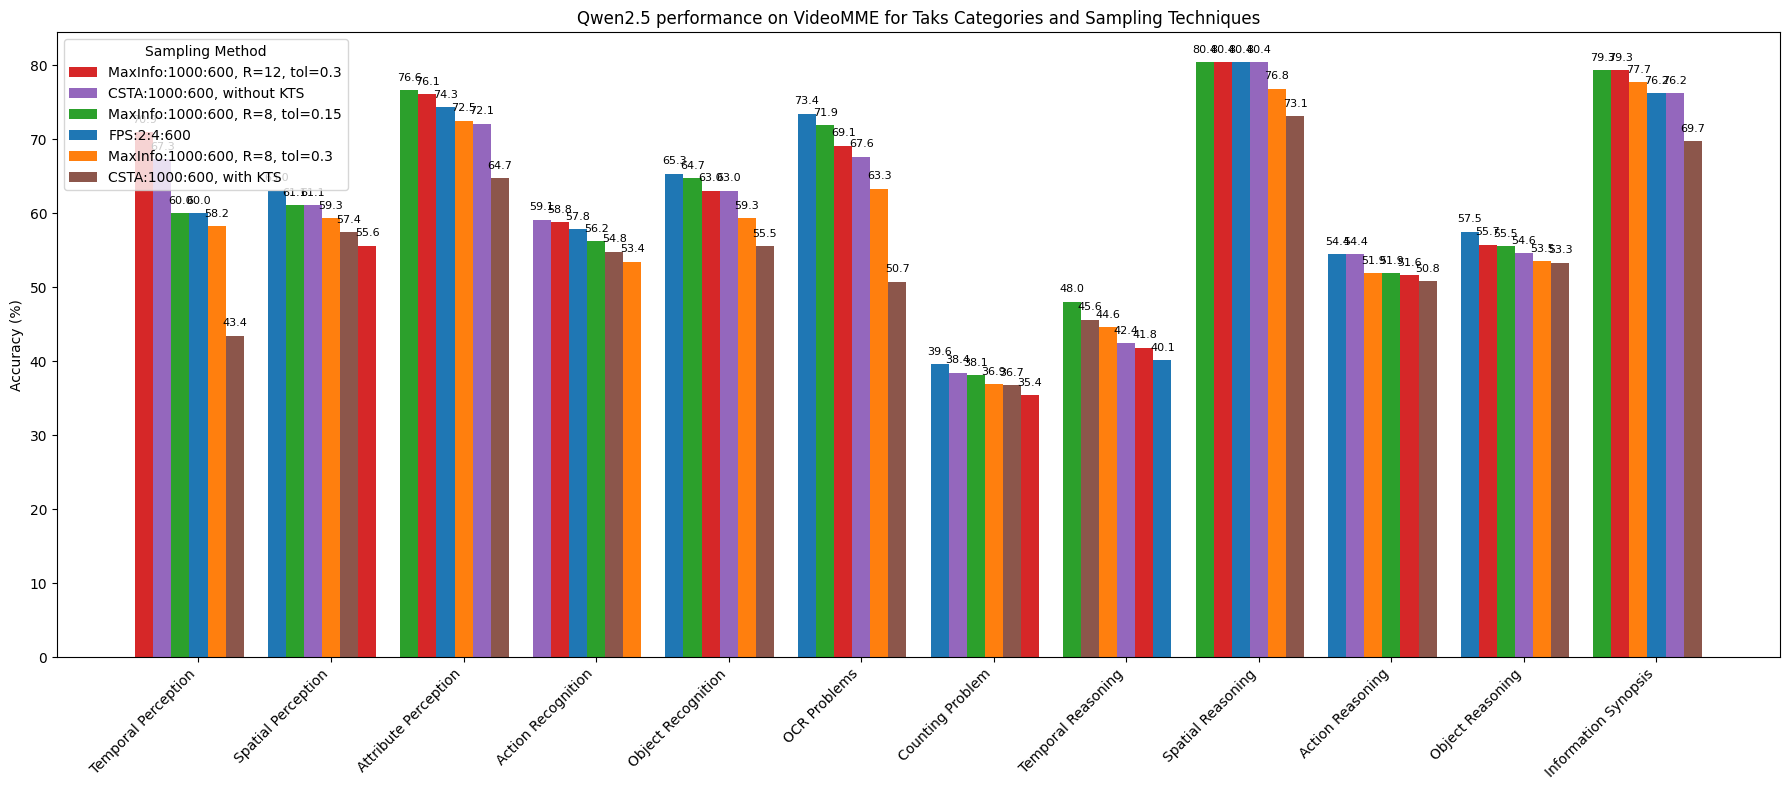

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "FPS:2:4:600": [60.0, 63.0, 74.3, 57.8, 65.3, 73.4, 39.6, 40.1, 80.4, 54.4, 57.5, 76.2],
    "MaxInfo:1000:600, R=8, tol=0.3": [58.2, 59.3, 72.5, 53.4, 59.3, 63.3, 36.9, 44.6, 76.8, 51.9, 53.5, 77.7],
    "MaxInfo:1000:600, R=8, tol=0.15": [60.0, 61.1, 76.6, 56.2, 64.7, 71.9, 38.1, 48.0, 80.4, 51.9, 55.5, 79.3],
    "MaxInfo:1000:600, R=12, tol=0.3": [70.9, 55.6, 76.1, 58.8, 63.0, 69.1, 35.4, 41.8, 80.4, 51.6, 55.7, 79.3],
    "CSTA:1000:600, without KTS": [67.3, 61.1, 72.1, 59.1, 63.0, 67.6, 38.4, 42.4, 80.4, 54.4, 54.6, 76.2],
    "CSTA:1000:600, with KTS": [43.4, 57.4, 64.7, 54.8, 55.5, 50.7, 36.7, 45.6, 73.1, 50.8, 53.3, 69.7]
}

df = pd.DataFrame(data)
sampling_methods = ["FPS:2:4:600", "MaxInfo:1000:600, R=8, tol=0.3", "MaxInfo:1000:600, R=8, tol=0.15", "MaxInfo:1000:600, R=12, tol=0.3", "CSTA:1000:600, without KTS", "CSTA:1000:600, with KTS"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("Qwen2.5 performance on VideoMME for Taks Categories and Sampling Techniques")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()


### Video categories

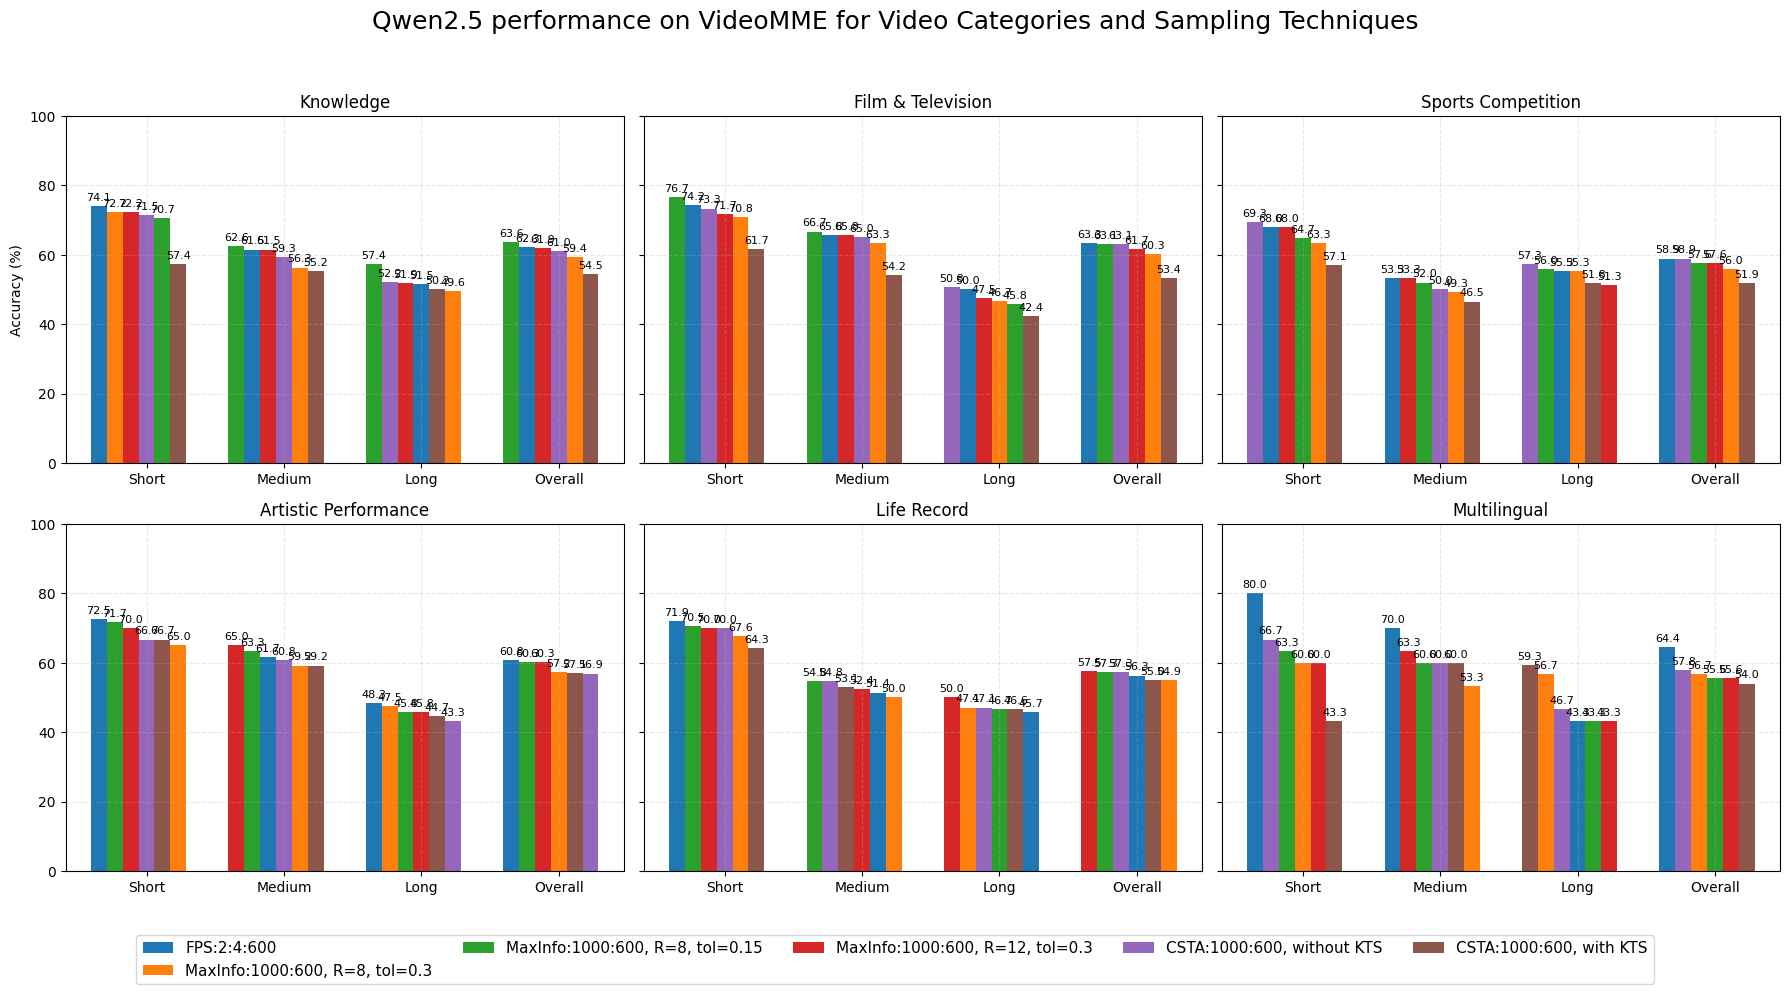

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

categories_fps = {
    "Knowledge": {
        "Short":   [74.1],
        "Medium":  [61.5],
        "Long":    [51.5],
        "Overall": [62.3],
    },
    "Film & Television": {
        "Short":   [74.2],
        "Medium":  [65.8],
        "Long":    [50.0],
        "Overall": [63.3],
    },
    "Sports Competition": {
        "Short":   [68.0],
        "Medium":  [53.3],
        "Long":    [55.3],
        "Overall": [58.9],
    },
    "Artistic Performance": {
        "Short":   [72.5],
        "Medium":  [61.7],
        "Long":    [48.3],
        "Overall": [60.8],
    },
    "Life Record": {
        "Short":   [71.9],
        "Medium":  [51.4],
        "Long":    [45.7],
        "Overall": [56.3],
    },
    "Multilingual": {
        "Short":   [80.0],
        "Medium":  [70.0],
        "Long":    [43.3],
        "Overall": [64.4],
    },
}
categories_maxinfo = {
    "Knowledge": {
        "Short":   [72.2, 70.7, 72.2],
        "Medium":  [56.3, 62.6, 61.5],
        "Long":    [49.6, 57.4, 51.9],
        "Overall": [59.4, 63.6, 61.9],
    },
    "Film & Television": {
        "Short":   [70.8, 76.7, 71.7],
        "Medium":  [63.3, 66.7, 65.8],
        "Long":    [46.7, 45.8, 47.5],
        "Overall": [60.3, 63.1, 61.7],
    },
    "Sports Competition": {
        "Short":   [63.3, 64.7, 68.0],
        "Medium":  [49.3, 52.0, 53.3],
        "Long":    [55.3, 56.0, 51.3],
        "Overall": [56.0, 57.6, 57.6],
    },
    "Artistic Performance": {
        "Short":   [65.0, 71.7, 70.0],
        "Medium":  [59.2, 63.3, 65.0],
        "Long":    [47.5, 45.8, 45.8],
        "Overall": [57.2, 60.3, 60.3],
    },
    "Life Record": {
        "Short":   [67.6, 70.5, 70.0],
        "Medium":  [50.0, 54.8, 52.4],
        "Long":    [47.1, 46.7, 50.0],
        "Overall": [54.9, 57.3, 57.5],
    },
    "Multilingual": {
        "Short":   [60.0, 63.3, 60.0],
        "Medium":  [53.3, 60.0, 63.3],
        "Long":    [56.7, 43.3, 43.3],
        "Overall": [56.7, 55.6, 55.6],
    },
}
categories_csta = {
    "Knowledge": {
        "Short":   [71.5, 57.4],
        "Medium":  [59.3, 55.2],
        "Long":    [52.2, 50.2],
        "Overall": [61.0, 54.5],
    },
    "Film & Television": {
        "Short":   [73.3, 61.7],
        "Medium":  [65.0, 54.2],
        "Long":    [50.8, 42.4],
        "Overall": [63.1, 53.4],
    },
    "Sports Competition": {
        "Short":   [69.3, 57.1],
        "Medium":  [50.0, 46.5],
        "Long":    [57.3, 51.8],
        "Overall": [58.9, 51.9],
    },
    "Artistic Performance": {
        "Short":   [66.7, 66.7],
        "Medium":  [60.8, 59.2],
        "Long":    [43.3, 44.7],
        "Overall": [56.9, 57.1],
    },
    "Life Record": {
        "Short":   [70.0, 64.3],
        "Medium":  [54.8, 53.1],
        "Long":    [47.1, 46.6],
        "Overall": [57.3, 55.0],
    },
    "Multilingual": {
        "Short":   [66.7, 43.3],
        "Medium":  [60.0, 60.0],
        "Long":    [46.7, 59.3],
        "Overall": [57.8, 54.0],
    },
}

categories = {}

for cat in categories_fps.keys():  
    categories[cat] = {}
    for subcat in categories_fps[cat].keys(): 
        categories[cat][subcat] = (
            categories_fps[cat][subcat]
            + categories_maxinfo[cat][subcat]
            + categories_csta[cat][subcat]
        )


sampling_methods = ["FPS:2:4:600", "MaxInfo:1000:600, R=8, tol=0.3", "MaxInfo:1000:600, R=8, tol=0.15", "MaxInfo:1000:600, R=12, tol=0.3", "CSTA:1000:600, without KTS", "CSTA:1000:600, with KTS"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Qwen2.5 performance on VideoMME for Video Categories and Sampling Techniques", fontsize=18)

for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()


## 2000 initial frames for MaxInfo and CSTA

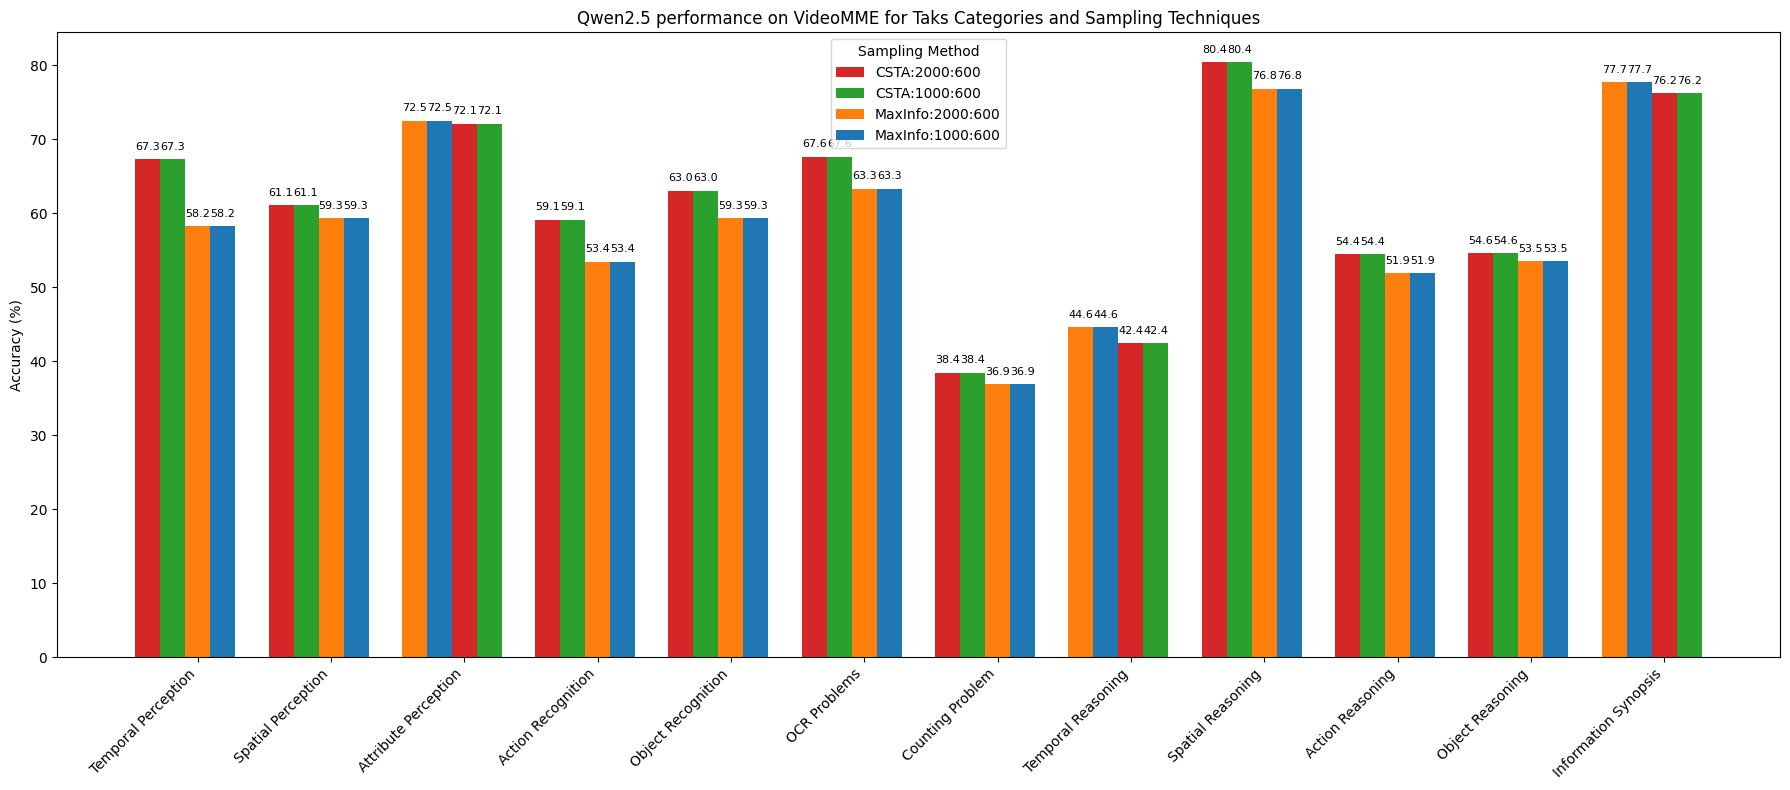

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "MaxInfo:1000:600": [58.2, 59.3, 72.5, 53.4, 59.3, 63.3, 36.9, 44.6, 76.8, 51.9, 53.5, 77.7],
    "MaxInfo:2000:600": [56.4, 57.4, 73.4, 56.5, 62.4, 64.0, 37.7, 40.7, 78.6, 53.0, 53.5, 75.9],
    "CSTA:1000:600": [67.3, 61.1, 72.1, 59.1, 63.0, 67.6, 38.4, 42.4, 80.4, 54.4, 54.6, 76.2],
    "CSTA:2000:600": [67.3, 61.1, 72.1, 59.1, 63.0, 67.6, 38.4, 42.4, 80.4, 54.4, 54.6, 76.2],
}

df = pd.DataFrame(data)
sampling_methods = ["MaxInfo:1000:600", "MaxInfo:2000:600", "CSTA:1000:600", "CSTA:2000:600"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("Qwen2.5 performance on VideoMME for Taks Categories and Sampling Techniques")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()


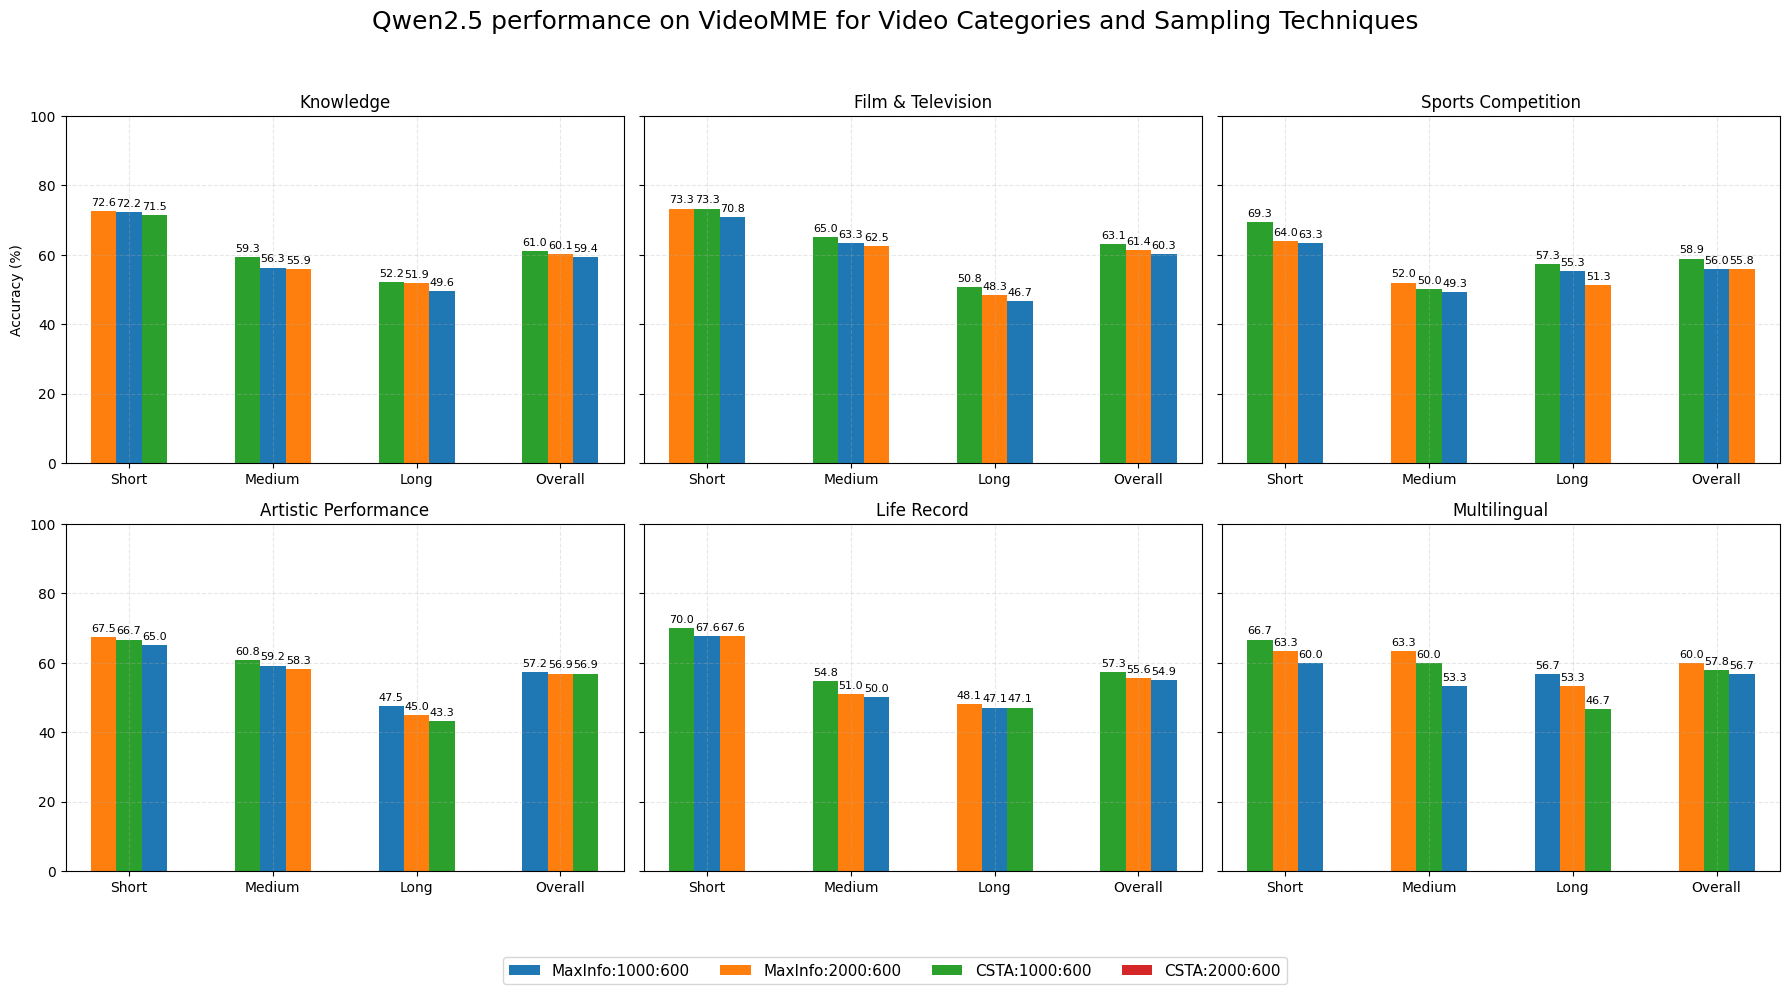

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

categories_maxinfo = {
    "Knowledge": {
        "Short":   [72.2, 72.6],
        "Medium":  [56.3, 55.9],
        "Long":    [49.6, 51.9],
        "Overall": [59.4, 60.1],
    },
    "Film & Television": {
        "Short":   [70.8, 73.3],
        "Medium":  [63.3, 62.5],
        "Long":    [46.7, 48.3],
        "Overall": [60.3, 61.4],
    },
    "Sports Competition": {
        "Short":   [63.3, 64.0],
        "Medium":  [49.3, 52.0],
        "Long":    [55.3, 51.3],
        "Overall": [56.0, 55.8],
    },
    "Artistic Performance": {
        "Short":   [65.0, 67.5],
        "Medium":  [59.2, 58.3],
        "Long":    [47.5, 45.0],
        "Overall": [57.2, 56.9],
    },
    "Life Record": {
        "Short":   [67.6, 67.6],
        "Medium":  [50.0, 51.0],
        "Long":    [47.1, 48.1],
        "Overall": [54.9, 55.6],
    },
    "Multilingual": {
        "Short":   [60.0, 63.3],
        "Medium":  [53.3, 63.3],
        "Long":    [56.7, 53.3],
        "Overall": [56.7, 60.0],
    },
}
categories_csta = {
    "Knowledge": {
        "Short":   [71.5, ],
        "Medium":  [59.3, ],
        "Long":    [52.2, ],
        "Overall": [61.0, ],
    },
    "Film & Television": {
        "Short":   [73.3, ],
        "Medium":  [65.0, ],
        "Long":    [50.8, ],
        "Overall": [63.1, ],
    },
    "Sports Competition": {
        "Short":   [69.3, ],
        "Medium":  [50.0, ],
        "Long":    [57.3, ],
        "Overall": [58.9, ],
    },
    "Artistic Performance": {
        "Short":   [66.7, ],
        "Medium":  [60.8, ],
        "Long":    [43.3, ],
        "Overall": [56.9, ],
    },
    "Life Record": {
        "Short":   [70.0, ],
        "Medium":  [54.8, ],
        "Long":    [47.1, ],
        "Overall": [57.3, ],
    },
    "Multilingual": {
        "Short":   [66.7, ],
        "Medium":  [60.0, ],
        "Long":    [46.7, ],
        "Overall": [57.8, ],
    },
}

categories = {}

for cat in categories_maxinfo.keys():  
    categories[cat] = {}
    for subcat in categories_maxinfo[cat].keys(): 
        categories[cat][subcat] = (categories_maxinfo[cat][subcat]
            + categories_csta[cat][subcat]
        )


sampling_methods = ["MaxInfo:1000:600", "MaxInfo:2000:600","CSTA:1000:600", "CSTA:2000:600"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Qwen2.5 performance on VideoMME for Video Categories and Sampling Techniques", fontsize=18)

for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()


# SmolVLM

## Video task

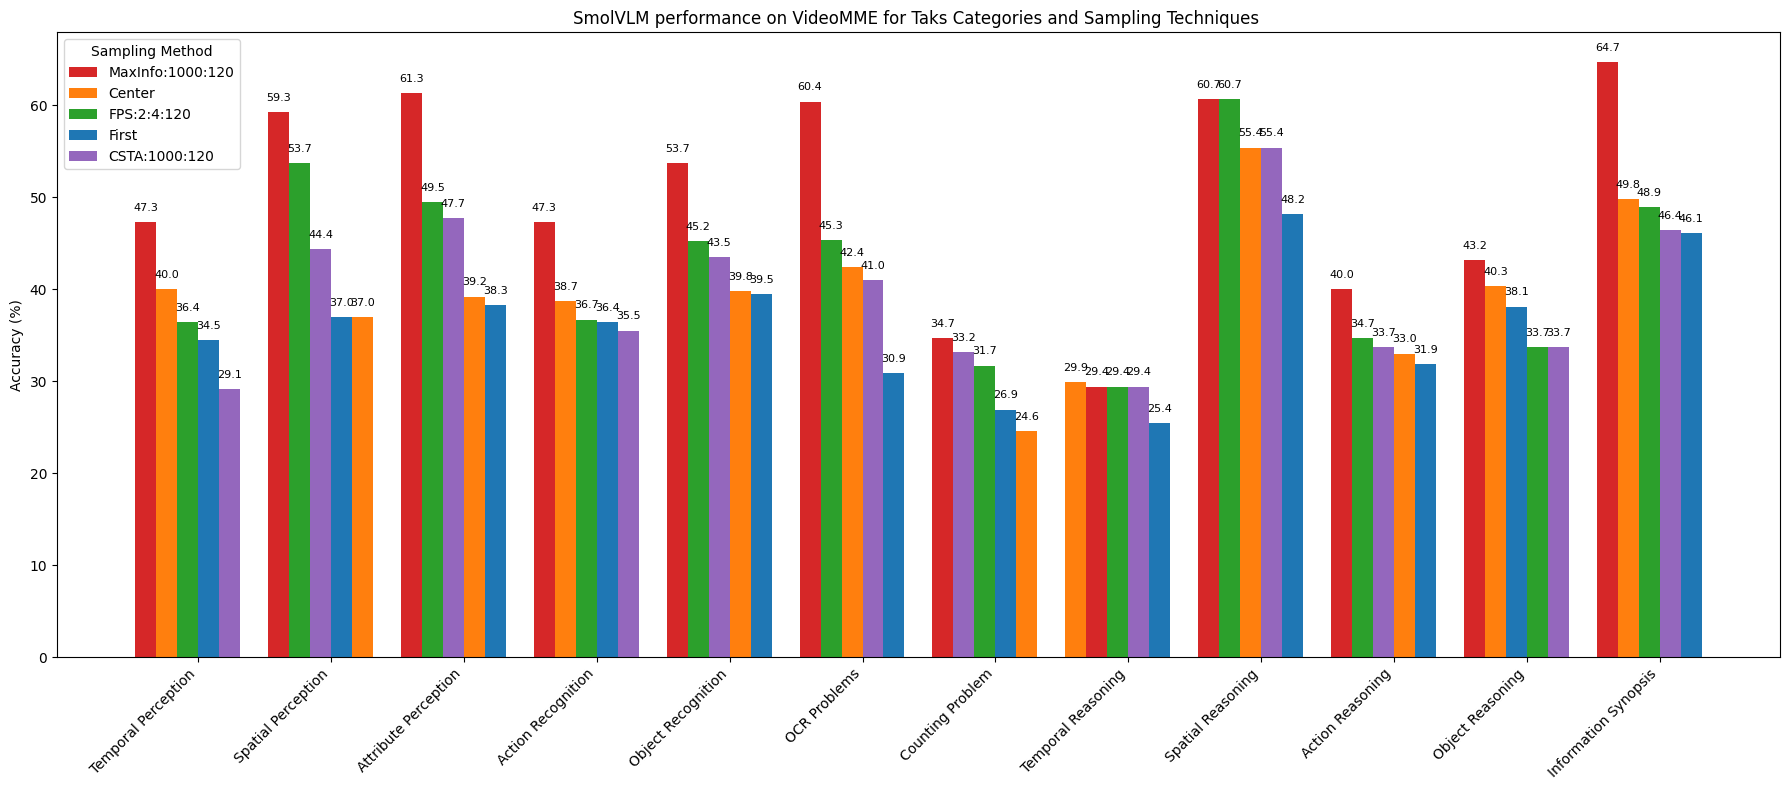

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "First": [34.5, 37.0, 38.3, 36.4, 39.5, 30.9, 26.9, 25.4, 48.2, 31.9, 38.1, 46.1],
    "Center": [40.0, 37.0, 39.2, 38.7, 39.8, 42.4, 24.6, 29.9, 55.4, 33.0, 40.3, 49.8],
    "FPS:2:4:120": [36.4, 53.7, 49.5, 36.7, 45.2, 45.3, 31.7, 29.4, 60.7, 34.7, 33.7, 48.9],
    "MaxInfo:1000:120": [47.3, 59.3, 61.3, 47.3, 53.7, 60.4, 34.7, 29.4, 60.7, 40.0, 43.2, 64.7],
    "CSTA:1000:120": [29.1, 44.4, 47.7, 35.5, 43.5, 41.0, 33.2, 29.4, 55.4, 33.7, 33.7, 46.4]
}

df = pd.DataFrame(data)
tasks = df["Task"]
sampling_methods = ["First", "Center", "FPS:2:4:120", "MaxInfo:1000:120", "CSTA:1000:120"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("SmolVLM performance on VideoMME for Taks Categories and Sampling Techniques ")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()



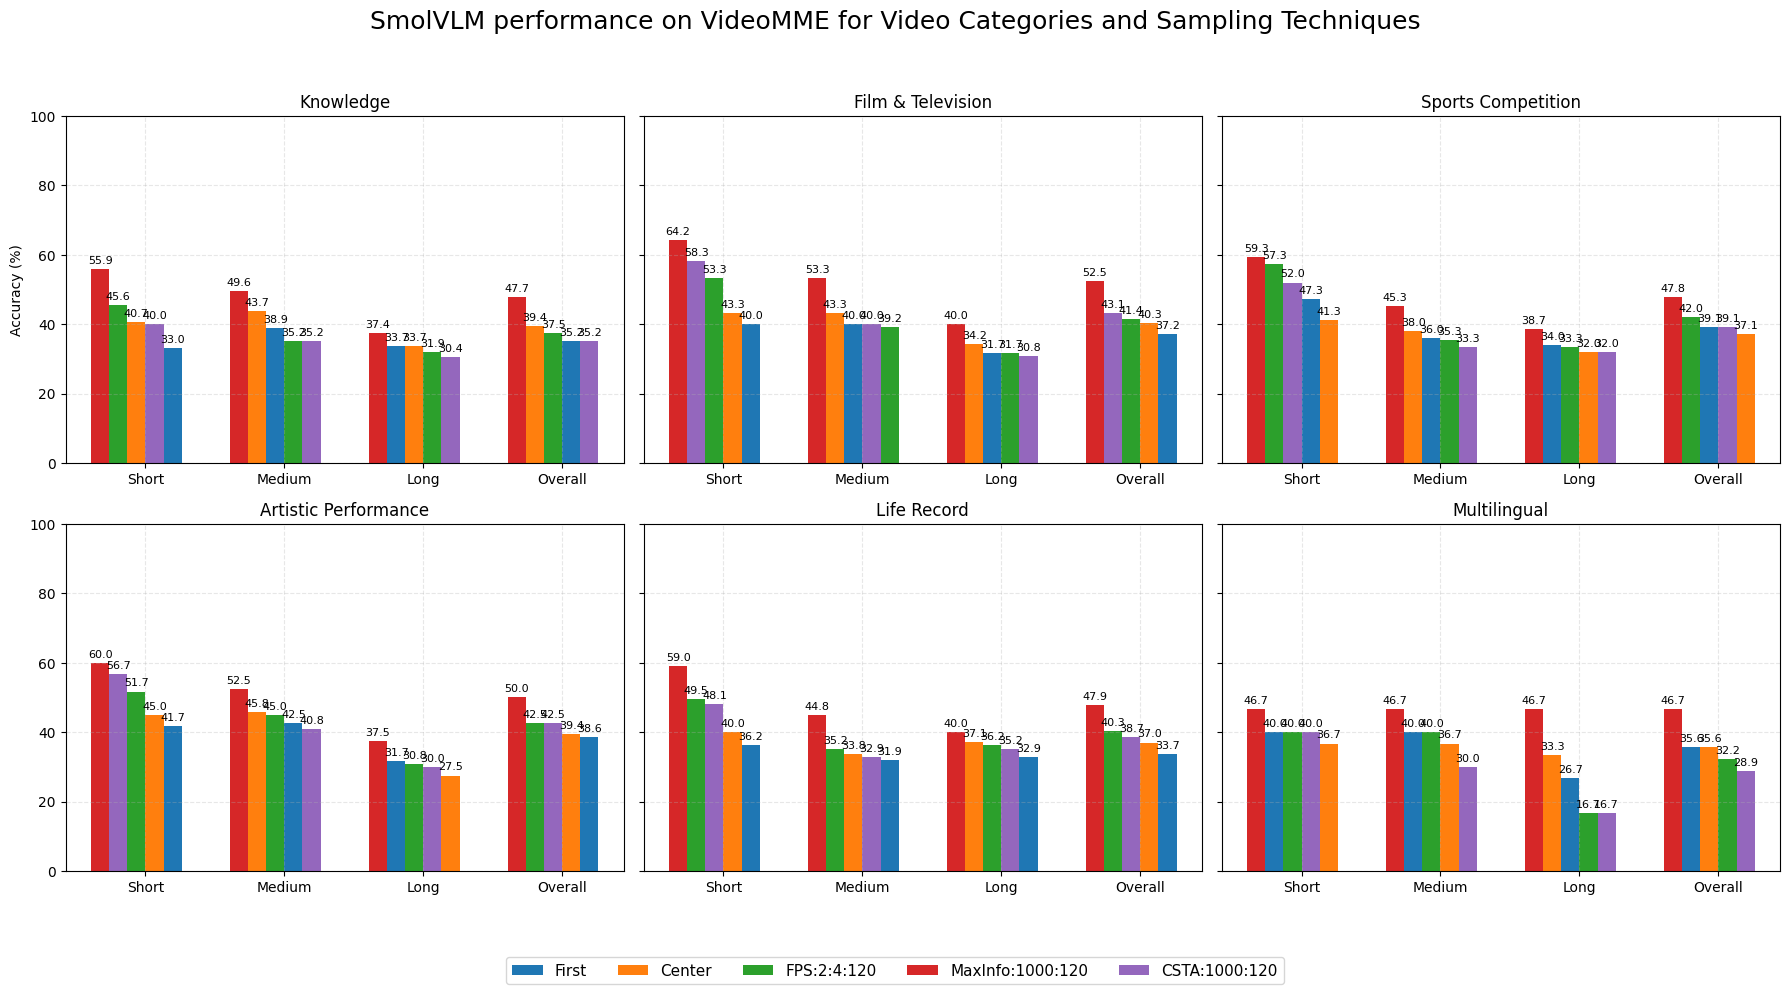

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


categories = {
    "Knowledge": {
        "Short":   [33.0, 40.7, 45.6, 55.9, 40.0],
        "Medium":  [38.9, 43.7, 35.2, 49.6, 35.2],
        "Long":    [33.7, 33.7, 31.9, 37.4, 30.4],
        "Overall": [35.2, 39.4, 37.5, 47.7, 35.2],
    },
    "Film & Television": {
        "Short":   [40.0, 43.3, 53.3, 64.2, 58.3],
        "Medium":  [40.0, 43.3, 39.2, 53.3, 40.0],
        "Long":    [31.7, 34.2, 31.7, 40.0, 30.8],
        "Overall": [37.2, 40.3, 41.4, 52.5, 43.1],
    },
    "Sports Competition": {
        "Short":   [47.3, 41.3, 57.3, 59.3, 52.0],
        "Medium":  [36.0, 38.0, 35.3, 45.3, 33.3],
        "Long":    [34.0, 32.0, 33.3, 38.7, 32.0],
        "Overall": [39.1, 37.1, 42.0, 47.8, 39.1],
    },
    "Artistic Performance": {
        "Short":   [41.7, 45.0, 51.7, 60.0, 56.7],
        "Medium":  [42.5, 45.8, 45.0, 52.5, 40.8],
        "Long":    [31.7, 27.5, 30.8, 37.5, 30.0],
        "Overall": [38.6, 39.4, 42.5, 50.0, 42.5],
    },
    "Life Record": {
        "Short":   [36.2, 40.0, 49.5, 59.0, 48.1],
        "Medium":  [31.9, 33.8, 35.2, 44.8, 32.9],
        "Long":    [32.9, 37.1, 36.2, 40.0, 35.2],
        "Overall": [33.7, 37.0, 40.3, 47.9, 38.7],
    },
    "Multilingual": {
        "Short":   [40.0, 36.7, 40.0, 46.7, 40.0],
        "Medium":  [40.0, 36.7, 40.0, 46.7, 30.0],
        "Long":    [26.7, 33.3, 16.7, 46.7, 16.7],
        "Overall": [35.6, 35.6, 32.2, 46.7, 28.9],
    },
}


sampling_methods = ["First", "Center", "FPS:2:4:120", "MaxInfo:1000:120", "CSTA:1000:120"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))


fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("SmolVLM performance on VideoMME for Video Categories and Sampling Techniques", fontsize=18)


for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()

## With 96 maximum nuber of frames

### Video tasks

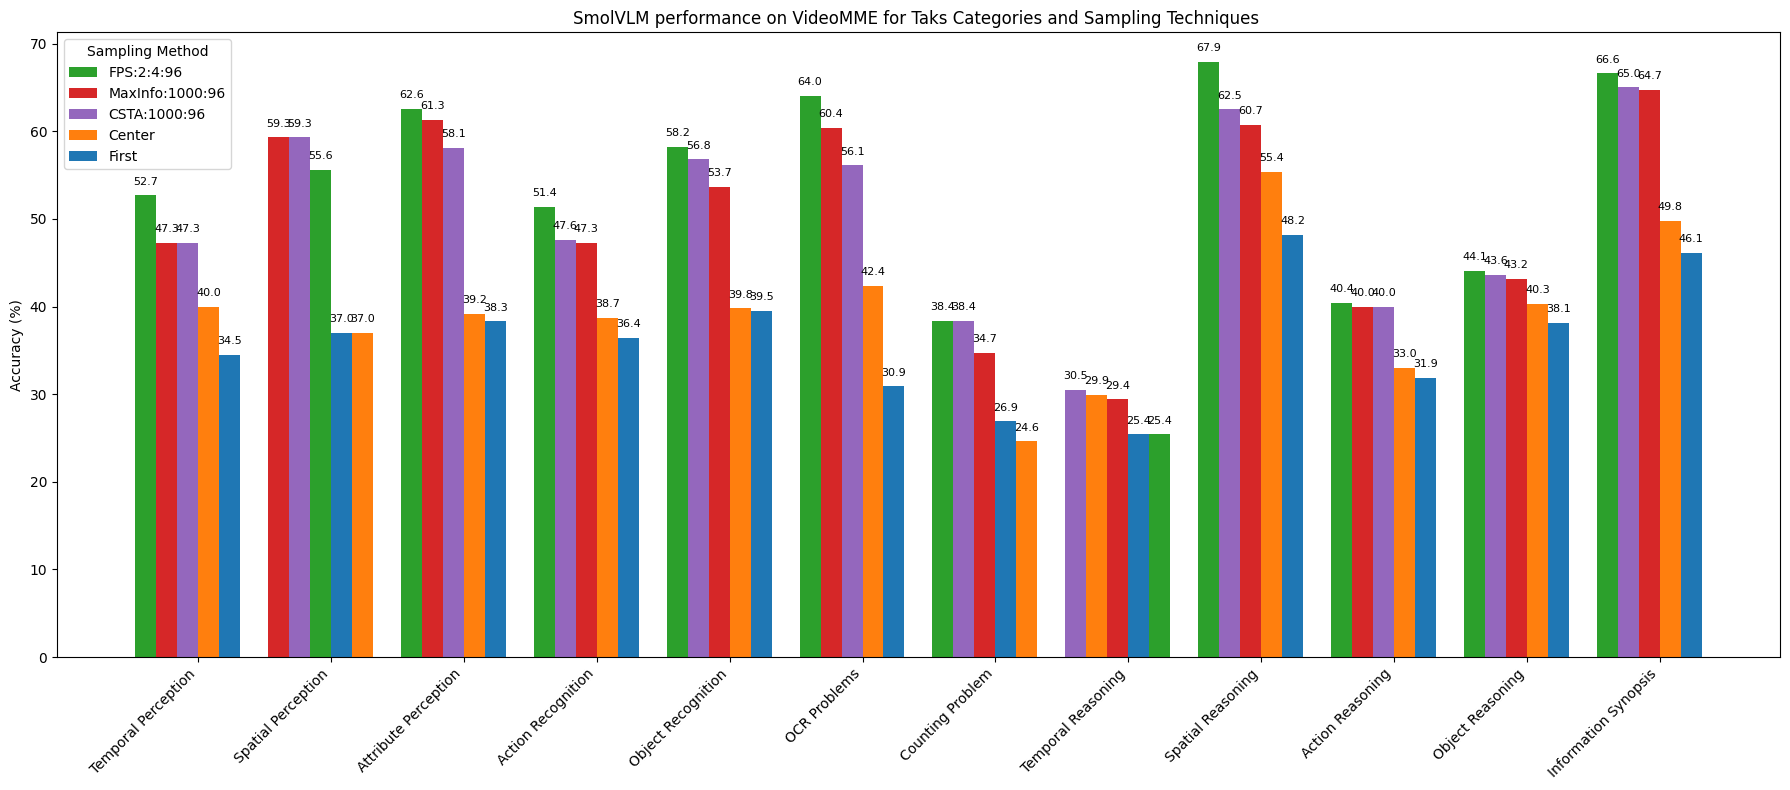

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "First": [34.5, 37.0, 38.3, 36.4, 39.5, 30.9, 26.9, 25.4, 48.2, 31.9, 38.1, 46.1],
    "Center": [40.0, 37.0, 39.2, 38.7, 39.8, 42.4, 24.6, 29.9, 55.4, 33.0, 40.3, 49.8],
    "FPS:2:4:96": [52.7, 55.6, 62.6, 51.4, 58.2, 64.0, 38.4, 25.4, 67.9, 40.4, 44.1, 66.6],
    "MaxInfo:1000:96": [47.3, 59.3, 61.3, 47.3, 53.7, 60.4, 34.7, 29.4, 60.7, 40.0, 43.2, 64.7],
    "CSTA:1000:96": [47.3, 59.3, 58.1, 47.6, 56.8, 56.1, 38.4, 30.5, 62.5, 40.0, 43.6, 65.0]
}

df = pd.DataFrame(data)
tasks = df["Task"]
sampling_methods = ["First", "Center", "FPS:2:4:96", "MaxInfo:1000:96", "CSTA:1000:96"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("SmolVLM performance on VideoMME for Taks Categories and Sampling Techniques ")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()



### Video categories

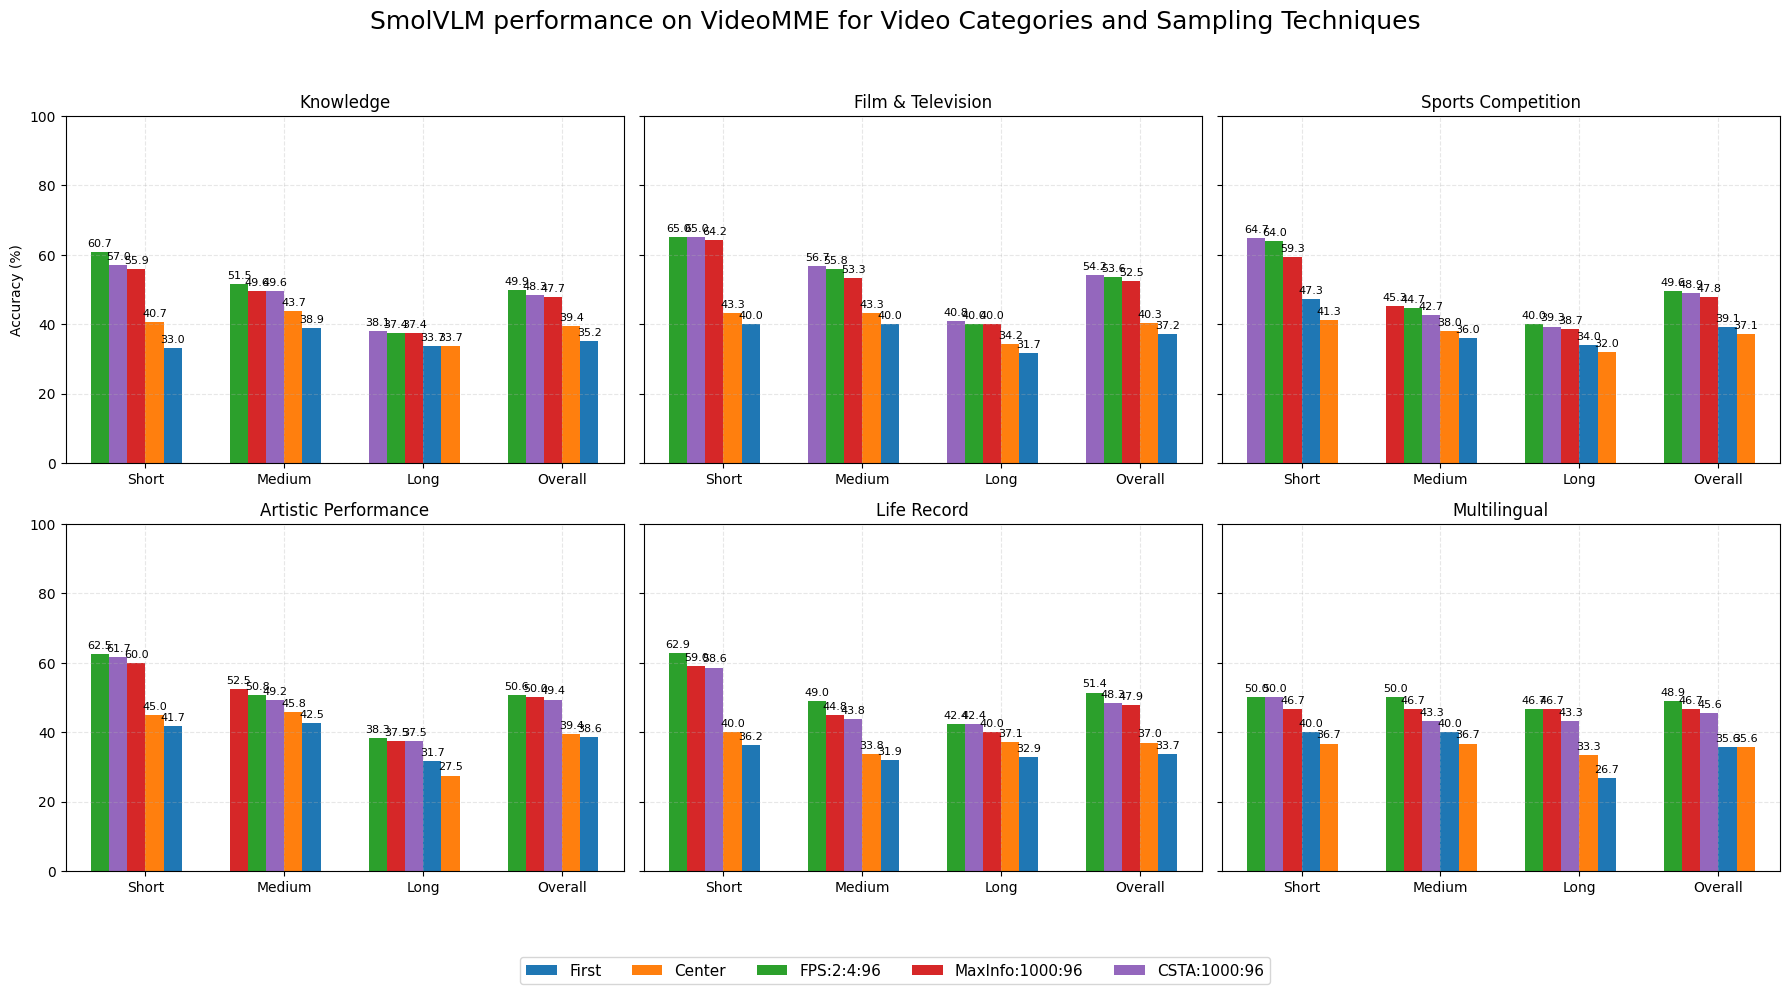

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


categories = {
    "Knowledge": {
        "Short":   [33.0, 40.7, 60.7, 55.9, 57.0],
        "Medium":  [38.9, 43.7, 51.5, 49.6, 49.6],
        "Long":    [33.7, 33.7, 37.4, 37.4, 38.1],
        "Overall": [35.2, 39.4, 49.9, 47.7, 48.3],
    },
    "Film & Television": {
        "Short":   [40.0, 43.3, 65.0, 64.2, 65.0],
        "Medium":  [40.0, 43.3, 55.8, 53.3, 56.7],
        "Long":    [31.7, 34.2, 40.0, 40.0, 40.8],
        "Overall": [37.2, 40.3, 53.6, 52.5, 54.2],
    },
    "Sports Competition": {
        "Short":   [47.3, 41.3, 64.0, 59.3, 64.7],
        "Medium":  [36.0, 38.0, 44.7, 45.3, 42.7],
        "Long":    [34.0, 32.0, 40.0, 38.7, 39.3],
        "Overall": [39.1, 37.1, 49.6, 47.8, 48.9],
    },
    "Artistic Performance": {
        "Short":   [41.7, 45.0, 62.5, 60.0, 61.7],
        "Medium":  [42.5, 45.8, 50.8, 52.5, 49.2],
        "Long":    [31.7, 27.5, 38.3, 37.5, 37.5],
        "Overall": [38.6, 39.4, 50.6, 50.0, 49.4],
    },
    "Life Record": {
        "Short":   [36.2, 40.0, 62.9, 59.0, 58.6],
        "Medium":  [31.9, 33.8, 49.0, 44.8, 43.8],
        "Long":    [32.9, 37.1, 42.4, 40.0, 42.4],
        "Overall": [33.7, 37.0, 51.4, 47.9, 48.3],
    },
    "Multilingual": {
        "Short":   [40.0, 36.7, 50.0, 46.7, 50.0],
        "Medium":  [40.0, 36.7, 50.0, 46.7, 43.3],
        "Long":    [26.7, 33.3, 46.7, 46.7, 43.3],
        "Overall": [35.6, 35.6, 48.9, 46.7, 45.6],
    },
}


sampling_methods = ["First", "Center", "FPS:2:4:96", "MaxInfo:1000:96", "CSTA:1000:96"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))


fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("SmolVLM performance on VideoMME for Video Categories and Sampling Techniques", fontsize=18)


for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()

# Intern

## Task Categories

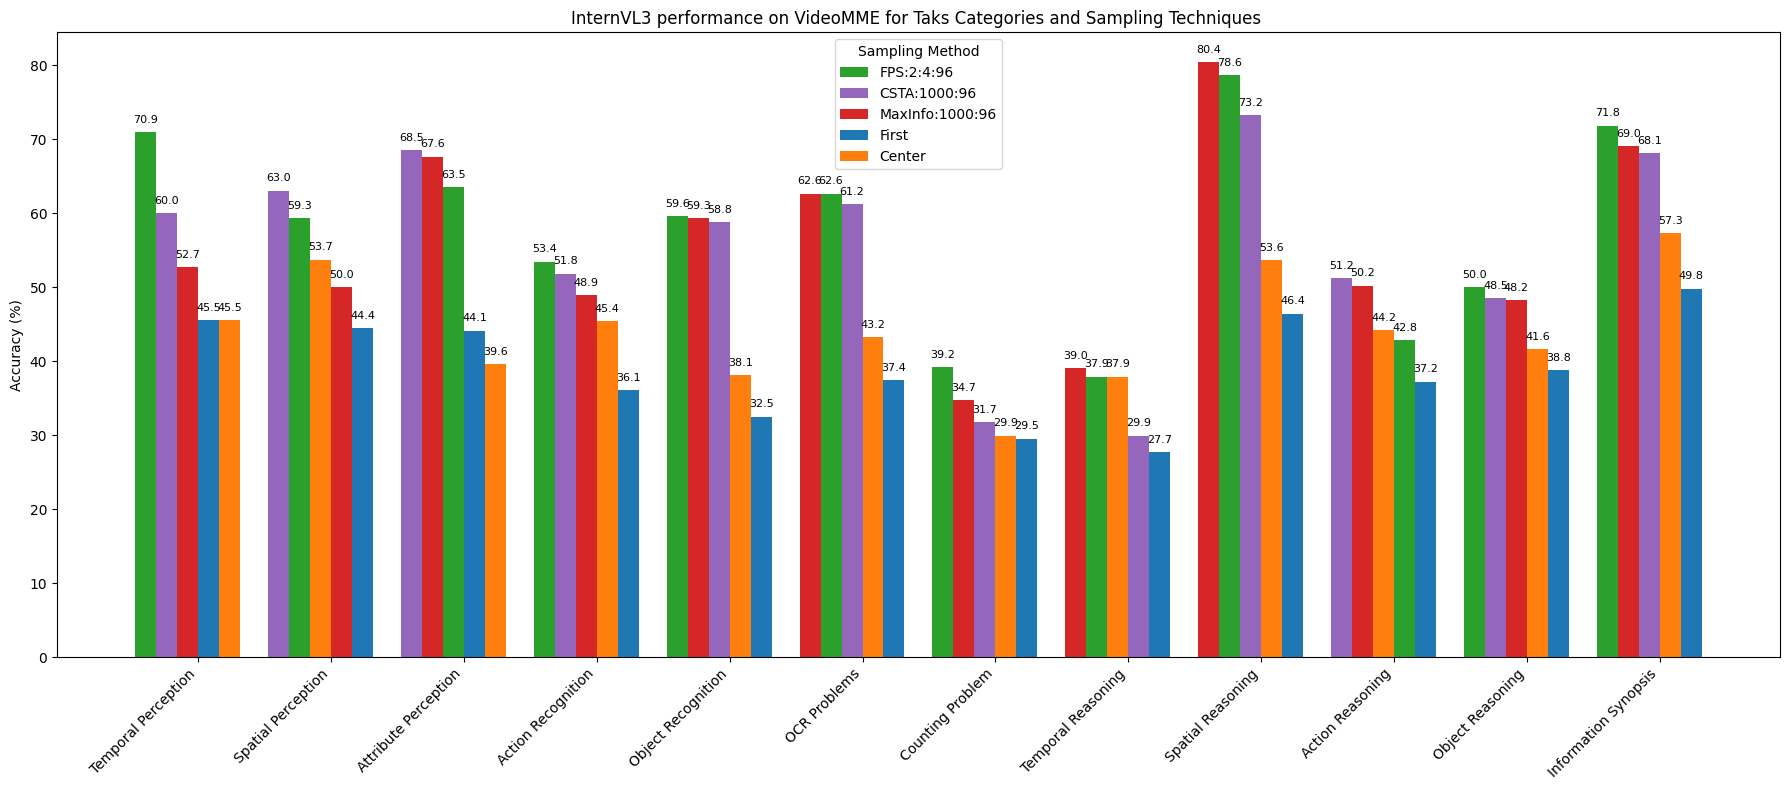

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "First": [45.5, 44.4, 44.1, 36.1, 32.5, 37.4, 29.5, 27.7, 46.4, 37.2, 38.8, 49.8],
    "Center": [45.5, 53.7, 39.6, 45.4, 38.1, 43.2, 29.9, 37.9, 53.6, 44.2, 41.6, 57.3],
    "FPS:2:4:96": [70.9, 59.3, 63.5, 53.4, 59.6, 62.6, 39.2, 37.9, 78.6, 42.8, 50.0, 71.8],
    "MaxInfo:1000:96": [52.7, 50.0, 67.6, 48.9, 59.3, 62.6, 34.7, 39.0, 80.4, 50.2, 48.2, 69.0],
    "CSTA:1000:96": [60.0, 63.0, 68.5, 51.8, 58.8, 61.2, 31.7, 29.9, 73.2, 51.2, 48.5, 68.1],
}

df = pd.DataFrame(data)
tasks = df["Task"]
sampling_methods = ["First", "Center", "FPS:2:4:96", "MaxInfo:1000:96", "CSTA:1000:96"]

colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("InternVL3 performance on VideoMME for Taks Categories and Sampling Techniques ")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()



## Video Categories

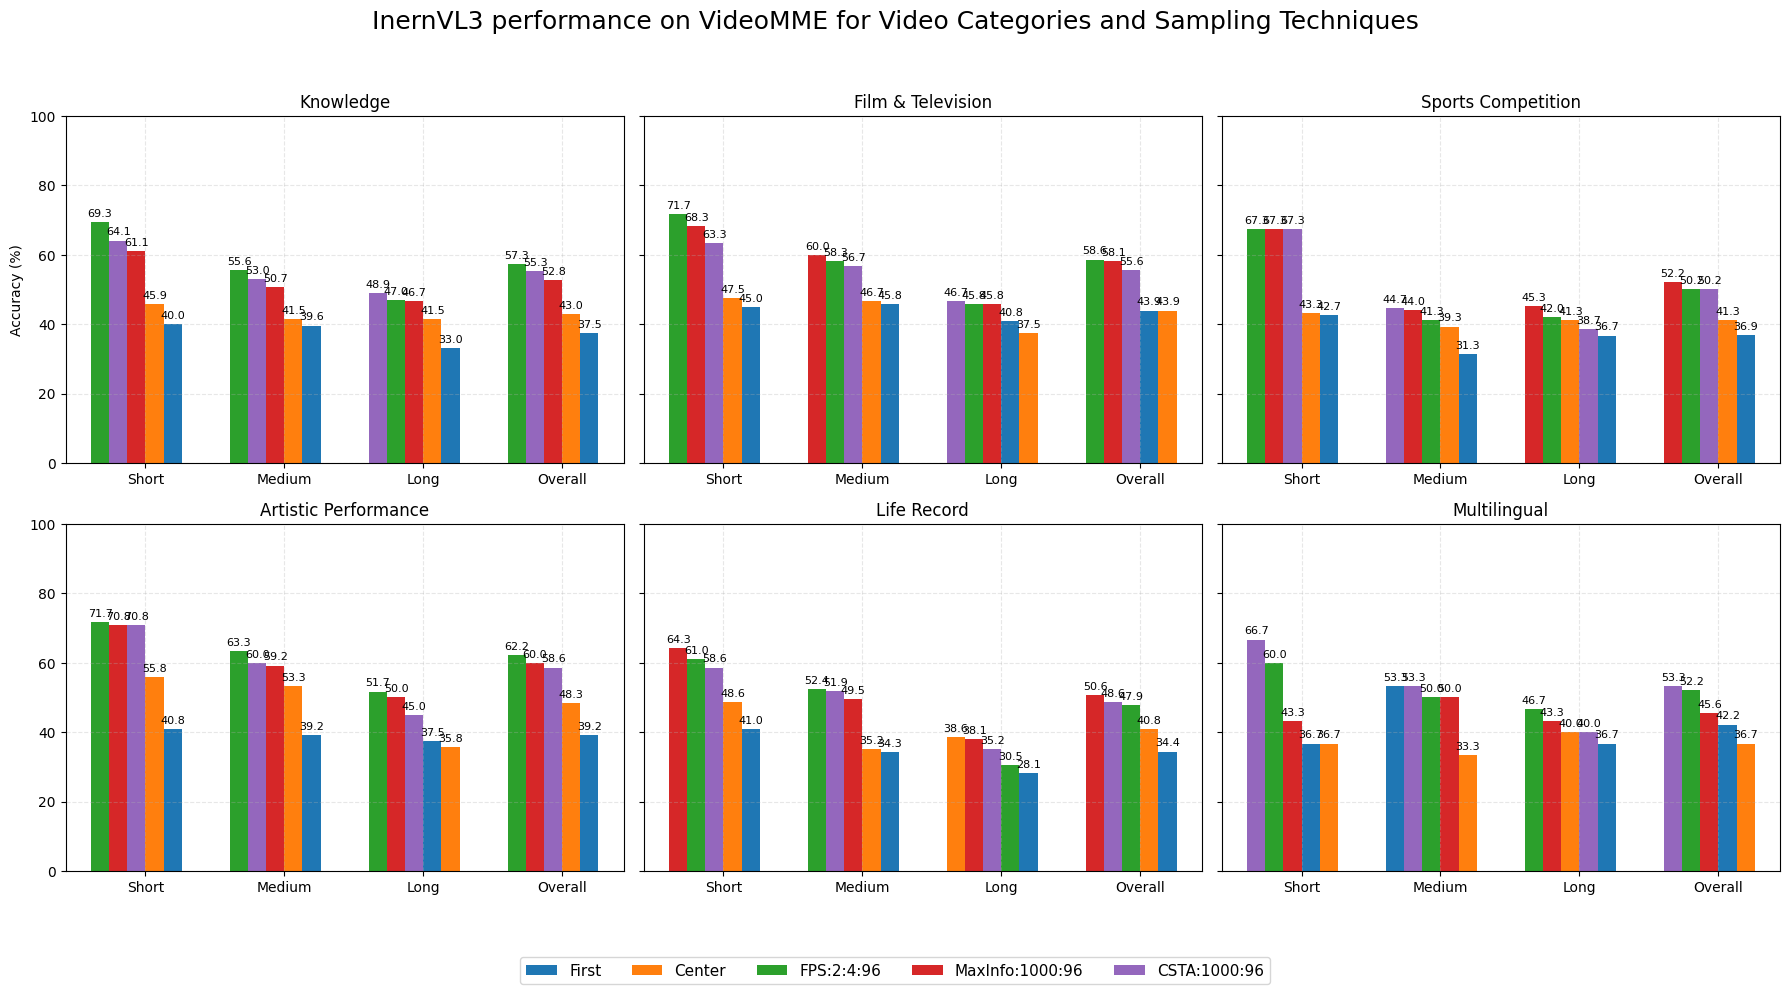

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


categories = {
    "Knowledge": {
        "Short":   [40.0, 45.9, 69.3, 61.1, 64.1],
        "Medium":  [39.6, 41.5, 55.6, 50.7, 53.0],
        "Long":    [33.0, 41.5, 47.0, 46.7, 48.9],
        "Overall": [37.5, 43.0, 57.3, 52.8, 55.3],
    },
    "Film & Television": {
        "Short":   [45.0, 47.5, 71.7, 68.3, 63.3],
        "Medium":  [45.8, 46.7, 58.3, 60.0, 56.7],
        "Long":    [40.8, 37.5, 45.8, 45.8, 46.7],
        "Overall": [43.9, 43.9, 58.6, 58.1, 55.6],
    },
    "Sports Competition": {
        "Short":   [42.7, 43.3, 67.3, 67.3, 67.3],
        "Medium":  [31.3, 39.3, 41.3, 44.0, 44.7],
        "Long":    [36.7, 41.3, 42.0, 45.3, 38.7],
        "Overall": [36.9, 41.3, 50.2, 52.2, 50.2],
    },
    "Artistic Performance": {
        "Short":   [40.8, 55.8, 71.7, 70.8, 70.8],
        "Medium":  [39.2, 53.3, 63.3, 59.2, 60.0],
        "Long":    [37.5, 35.8, 51.7, 50.0, 45.0],
        "Overall": [39.2, 48.3, 62.2, 60.0, 58.6],
    },
    "Life Record": {
        "Short":   [41.0, 48.6, 61.0, 64.3, 58.6],
        "Medium":  [34.3, 35.2, 52.4, 49.5, 51.9],
        "Long":    [28.1, 38.6, 30.5, 38.1, 35.2],
        "Overall": [34.4, 40.8, 47.9, 50.6, 48.6],
    },
    "Multilingual": {
        "Short":   [36.7, 36.7, 60.0, 43.3, 66.7],
        "Medium":  [53.3, 33.3, 50.0, 50.0, 53.3],
        "Long":    [36.7, 40.0, 46.7, 43.3, 40.0],
        "Overall": [42.2, 36.7, 52.2, 45.6, 53.3],
    },
}


sampling_methods = ["First", "Center", "FPS:2:4:96", "MaxInfo:1000:96", "CSTA:1000:96"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))


fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("InernVL3 performance on VideoMME for Video Categories and Sampling Techniques", fontsize=18)


for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()


# Ovis

## Task categories

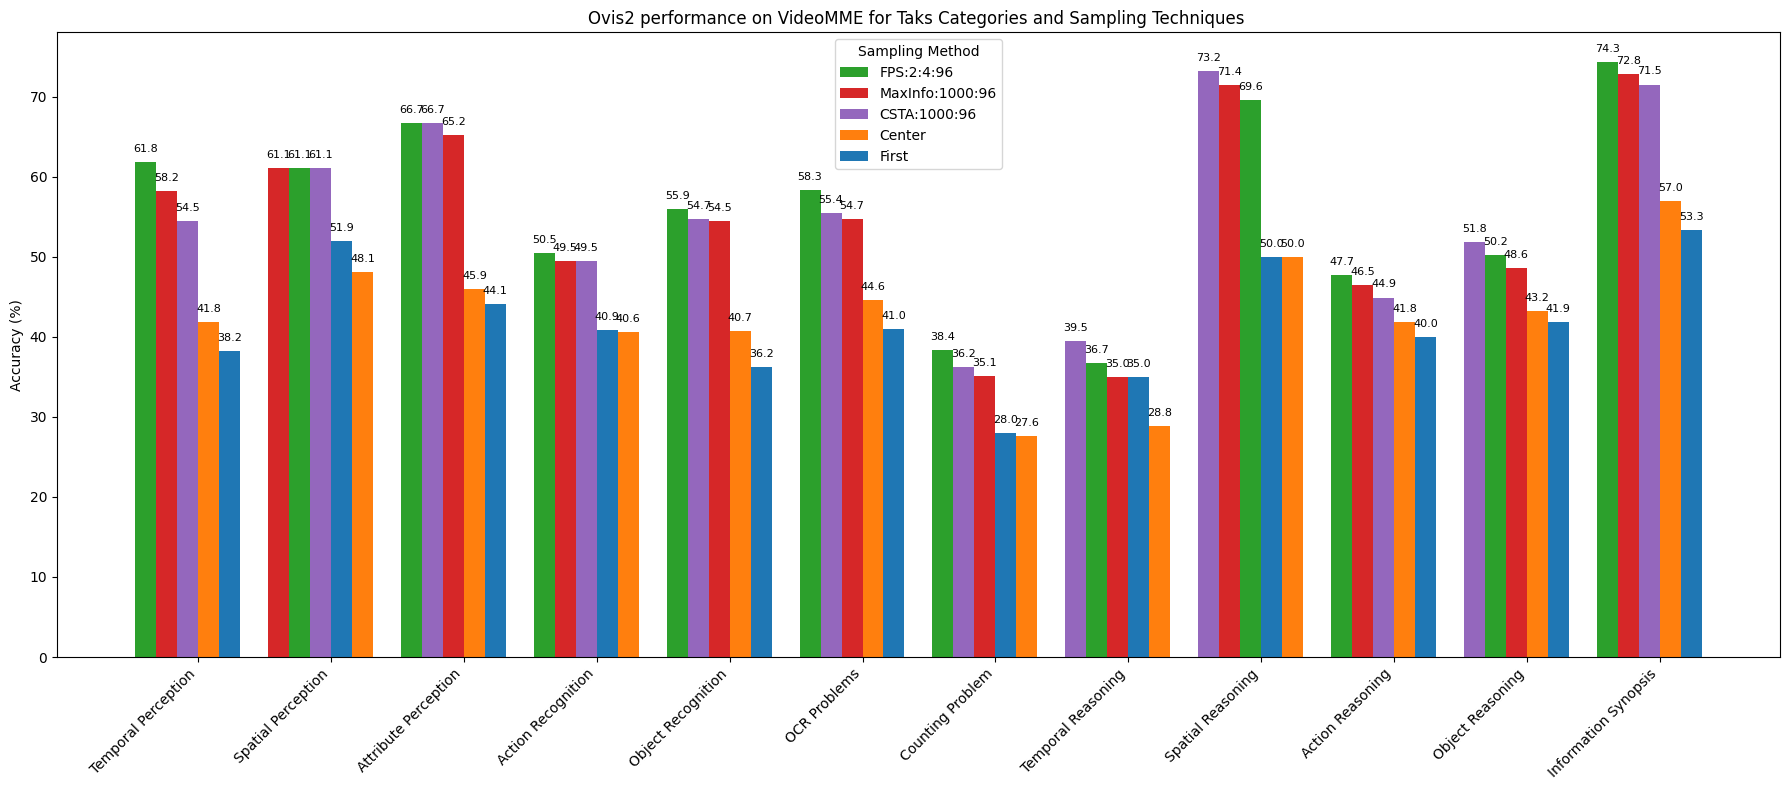

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Task performance data
data = {
    "Task": [
        "Temporal Perception", "Spatial Perception", "Attribute Perception", "Action Recognition",
        "Object Recognition", "OCR Problems", "Counting Problem", "Temporal Reasoning",
        "Spatial Reasoning", "Action Reasoning", "Object Reasoning", "Information Synopsis"
    ],
    "First": [38.2, 51.9, 44.1, 40.9, 36.2, 41.0, 28.0, 35.0, 50.0, 40.0, 41.9, 53.3],
    "Center": [41.8, 48.1, 45.9, 40.6, 40.7, 44.6, 27.6, 28.8, 50.0, 41.8, 43.2, 57.0],
    "FPS:2:4:96": [61.8, 61.1, 66.7, 50.5, 55.9, 58.3, 38.4, 36.7, 69.6, 47.7, 50.2, 74.3],
    "MaxInfo:1000:96": [58.2, 61.1, 65.2, 49.5, 54.5, 54.7, 35.1, 35.0, 71.4, 46.5, 48.6, 72.8],
    "CSTA:1000:96": [54.5, 61.1, 66.7, 49.5, 54.7, 55.4, 36.2, 39.5, 73.2, 44.9, 51.8, 71.5],
}

df = pd.DataFrame(data)
tasks = df["Task"]
sampling_methods = ["First", "Center", "FPS:2:4:96", "MaxInfo:1000:96", "CSTA:1000:96"]

colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))

bar_width = 0.15
gap = 0.2
fig, ax = plt.subplots(figsize=(18, 8))

x_pos = 0
xtick_positions = []
xtick_labels = []

# Iterate over tasks
for i, row in df.iterrows():
    task = row["Task"]
    values = row[sampling_methods]

    # Sort sampling methods by value for this task
    sorted_items = sorted(zip(values, sampling_methods), reverse=True)

    for j, (val, method) in enumerate(sorted_items):
        ax.bar(x_pos, val, width=bar_width, color=colors[method], label=method if i == 0 else "")
        ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
        x_pos += bar_width

    # Center of task group for tick
    xtick_center = x_pos - (bar_width * len(sampling_methods)) / 2
    xtick_positions.append(xtick_center)
    xtick_labels.append(task)

    # Add gap before next task
    x_pos += gap

# Set x-ticks in the center of each group
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')

ax.set_ylabel("Accuracy (%)")
ax.set_title("Ovis2 performance on VideoMME for Taks Categories and Sampling Techniques ")
ax.legend(title="Sampling Method")

plt.tight_layout()
plt.show()



# Video categories

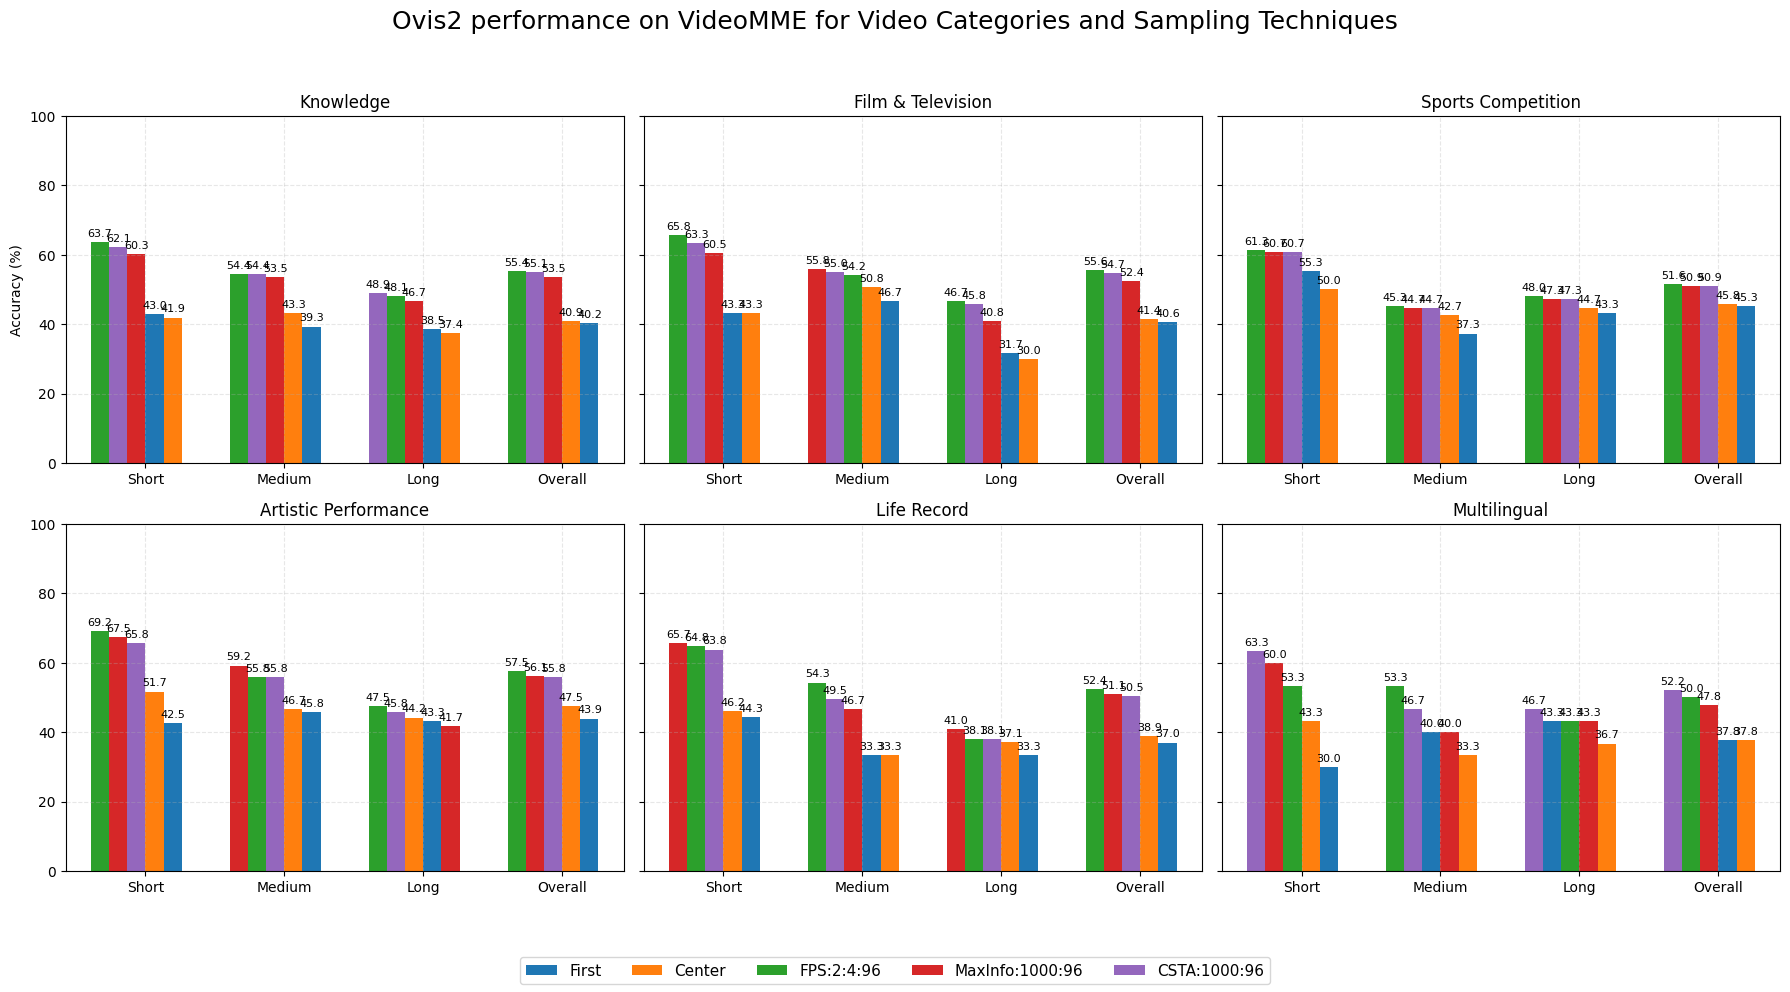

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch


categories = {
    "Knowledge": {
        "Short":   [43.0, 41.9, 63.7, 60.3, 62.1],
        "Medium":  [39.3, 43.3, 54.4, 53.5, 54.4],
        "Long":    [38.5, 37.4, 48.1, 46.7, 48.9],
        "Overall": [40.2, 40.9, 55.4, 53.5, 55.1],
    },
    "Film & Television": {
        "Short":   [43.3, 43.3, 65.8, 60.5, 63.3],
        "Medium":  [46.7, 50.8, 54.2, 55.8, 55.0],
        "Long":    [31.7, 30.0, 46.7, 40.8, 45.8],
        "Overall": [40.6, 41.4, 55.6, 52.4, 54.7],
    },
    "Sports Competition": {
        "Short":   [55.3, 50.0, 61.3, 60.7, 60.7],
        "Medium":  [37.3, 42.7, 45.3, 44.7, 44.7],
        "Long":    [43.3, 44.7, 48.0, 47.3, 47.3],
        "Overall": [45.3, 45.8, 51.6, 50.9, 50.9],
    },
    "Artistic Performance": {
        "Short":   [42.5, 51.7, 69.2, 67.5, 65.8],
        "Medium":  [45.8, 46.7, 55.8, 59.2, 55.8],
        "Long":    [43.3, 44.2, 47.5, 41.7, 45.8],
        "Overall": [43.9, 47.5, 57.5, 56.1, 55.8],
    },
    "Life Record": {
        "Short":   [44.3, 46.2, 64.8, 65.7, 63.8],
        "Medium":  [33.3, 33.3, 54.3, 46.7, 49.5],
        "Long":    [33.3, 37.1, 38.1, 41.0, 38.1],
        "Overall": [37.0, 38.9, 52.4, 51.1, 50.5],
    },
    "Multilingual": {
        "Short":   [30.0, 43.3, 53.3, 60.0, 63.3],
        "Medium":  [40.0, 33.3, 53.3, 40.0, 46.7],
        "Long":    [43.3, 36.7, 43.3, 43.3, 46.7],
        "Overall": [37.8, 37.8, 50.0, 47.8, 52.2],
    },
}


sampling_methods = ["First", "Center", "FPS:2:4:96", "MaxInfo:1000:96", "CSTA:1000:96"]
video_types = ["Short", "Medium", "Long", "Overall"]
colors = dict(zip(sampling_methods, plt.cm.tab10.colors[:len(sampling_methods)]))


fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
fig.suptitle("Ovis2 performance on VideoMME for Video Categories and Sampling Techniques", fontsize=18)


for ax, (cat_name, data) in zip(axs.flatten(), categories.items()):
    group_gap = 0.4  # spacing between video type groups
    bar_width = 0.15
    x_pos = 0
    tick_positions = []
    tick_labels = []

    for vt in video_types:
        values = data[vt]
        method_value_pairs = list(zip(sampling_methods, values))

        # Sort by value (descending) for visual order
        sorted_pairs = sorted(method_value_pairs, key=lambda x: x[1], reverse=True)

        for method, val in sorted_pairs:
            ax.bar(x_pos, val, width=bar_width, color=colors[method])
            ax.text(x_pos, val + 1, f"{val:.1f}", ha='center', va='bottom', fontsize=8)
            # Optional: display method name below bar
            #ax.text(x_pos, -5, method.split(":")[0], ha='center', va='top', fontsize=7, rotation=45)
            x_pos += bar_width

        tick_center = x_pos - (bar_width * len(sampling_methods)) / 2
        tick_positions.append(tick_center)
        tick_labels.append(vt)
        x_pos += group_gap

    ax.set_title(cat_name, fontsize=12)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle='--', alpha=0.3)

axs[0][0].set_ylabel("Accuracy (%)")
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

# ✅ Global legend (one color per method)
legend_elements = [Patch(facecolor=colors[m], label=m) for m in sampling_methods]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=11)

plt.show()
